# RegVelo Schwann PairScorer tutorial


        This notebook demonstrates a complete replicate-aware two-condition analysis of
        the curated Common Progenitor → Gut/Gut neuron/ChC furcation. In `DEMO_MODE`, a
        controlled transition tilt toward ChC validates the API. It does not represent a
        real treatment effect. Gut is allowed to remain retrograde.


> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Installation, versions, and analysis settings


In [1]:
from __future__ import annotations
import warnings

from pathlib import Path
import importlib.metadata as importlib_metadata
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from scipy.spatial.distance import jensenshannon

import scCS

SEED = 20260714
N_JOBS = 1
sc.settings.verbosity = 2
scv.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")

print("Python", sys.version.split()[0])
print("Platform", platform.platform())
print("scCS", scCS.__version__)
print("Scanpy", importlib_metadata.version("scanpy"))
print("scVelo", scv.__version__)

OUTPUT_DIR = Path("tutorial_outputs/schwann_pair")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hide known warnings emitted by optional upstream dependencies. These do not
# change the scCS calculation and would otherwise distract from the tutorial.
warnings.filterwarnings(
    "ignore",
    message=r"This process .* is multi-threaded, use of fork\(\) may lead to deadlocks.*",
    category=DeprecationWarning,
)
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=r"cellrank\..*",
)


Python 3.12.13
Platform Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
scCS 0.8.0.dev33
Scanpy 1.11.5
scVelo 0.3.4


In [2]:
DEMO_MODE = True
CONDITION_KEY = "condition"
REPLICATE_KEY = "sample_id"
CONDITIONS = ("control", "treated")
REPLICATES_PER_CONDITION = 5
RUN_SCOPE_SENSITIVITY = False
RUN_MIXED_MODEL_SENSITIVITY = False

## 2. Load the dataset and velocity graph

The Schwann tutorials use **dynamical RNA velocity** as the primary model.
The dataset is loaded directly from RegVelo and the velocity model is fitted in
the original expression/PCA manifold. No tutorial cache is assumed.

The inverse-CytoTRACE coordinate is used only as the validated ordering for this
particular furcation; scCS does not prescribe it as a universal pseudotime.



In [3]:
def clear_velocity_outputs(adata, *, clear_dynamics=False):
    """Remove stale velocity fields before fitting a requested model."""
    for key in ("velocity", "velocity_u", "velocity_variance"):
        adata.layers.pop(key, None)
    for key in ("velocity_graph", "velocity_graph_neg", "velocity_params"):
        adata.uns.pop(key, None)
    for key in (
        "velocity_self_transition",
        "root_cells",
        "end_points",
        "velocity_pseudotime",
        "latent_time",
    ):
        if key in adata.obs:
            del adata.obs[key]
    if clear_dynamics:
        for key in list(adata.var.columns):
            if str(key).startswith("fit_"):
                del adata.var[key]
        for key in list(adata.layers):
            if str(key).startswith("fit_"):
                del adata.layers[key]
        adata.uns.pop("recover_dynamics", None)


def ensure_pca_neighbors_moments(
    adata,
    *,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=False,
):
    """Create the unbiased PCA neighbor graph used by RNA velocity."""
    if "X_pca" not in adata.obsm:
        n_comps = min(n_pcs, adata.n_obs - 1, adata.n_vars - 1)
        sc.pp.pca(adata, n_comps=n_comps)
    if "neighbors" not in adata.uns or not preserve_existing_neighbors:
        sc.pp.neighbors(
            adata,
            n_neighbors=min(n_neighbors, adata.n_obs - 1),
            n_pcs=min(n_pcs, adata.obsm["X_pca"].shape[1]),
            use_rep="X_pca",
            random_state=SEED,
        )
    if not {"Ms", "Mu"}.issubset(adata.layers):
        scv.pp.moments(adata, n_neighbors=None, n_pcs=None)
    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata, random_state=SEED)


def resolve_present_genes(adata, candidates):
    """Resolve gene symbols case-insensitively and report missing markers."""
    lookup = {str(gene).lower(): str(gene) for gene in adata.var_names}
    resolved, missing = [], []
    for candidate in candidates:
        match = lookup.get(str(candidate).lower())
        if match is None:
            missing.append(str(candidate))
        elif match not in resolved:
            resolved.append(match)
    return resolved, missing


def row_js(left, right):
    """Row-wise Jensen-Shannon divergence with base-2 logarithms."""
    return np.asarray(
        [jensenshannon(a, b, base=2.0) ** 2 for a, b in zip(left, right)],
        dtype=float,
    )


def ordering_thirds(values):
    """Return stable early/middle/late labels for a continuous coordinate."""
    series = pd.Series(np.asarray(values, dtype=float))
    ranked = series.rank(method="first")
    return (
        pd.qcut(
            ranked,
            q=3,
            labels=["early", "middle", "late"],
            duplicates="drop",
        )
        .astype(str)
        .to_numpy()
    )

In [4]:
import regvelo as rgv

SCHWANN_CLUSTER_ANNOTATION = {
    "15": "Common Progenitor",
    "5": "Common Progenitor",
    "16": "Gut",
    "12": "Gut neuron",
    "8": "ChC",
    "6": "ChC",
}
VELOCITY_MODEL = "dynamical"
RECOVER_DYNAMICS_MAX_ITER = 20


def prepare_schwann_annotations(adata):
    """Reproduce the curated Schwann furcation and inverse-CytoTRACE ordering."""
    if "neighbors" not in adata.uns or "connectivities" not in adata.obsp:
        raise RuntimeError("The original RegVelo neighbor graph is required.")

    if "sccs_leiden" not in adata.obs:
        sc.tl.leiden(
            adata,
            resolution=1.0,
            random_state=0,
            key_added="sccs_leiden",
        )

    leiden = adata.obs["sccs_leiden"].astype(str)
    adata.obs["cell_type_new"] = (
        leiden.map(SCHWANN_CLUSTER_ANNOTATION).fillna("Other").astype("category")
    )

    required = ("Common Progenitor", "Gut", "Gut neuron", "ChC")
    counts = adata.obs["cell_type_new"].astype(str).value_counts().reindex(required, fill_value=0)
    if np.any(counts <= 0):
        raise ValueError(
            f"The curated furcation was not reproduced. Observed counts: {counts.to_dict()}"
        )

    cytotrace = pd.to_numeric(adata.obs["CytoTRACE"], errors="coerce").to_numpy(float)
    finite = np.isfinite(cytotrace)
    lower = float(np.nanmin(cytotrace))
    upper = float(np.nanmax(cytotrace))
    inverse = np.full(adata.n_obs, np.nan, dtype=float)
    inverse[finite] = 1.0 - (cytotrace[finite] - lower) / (upper - lower)
    adata.obs["inverse_cytotrace_pseudotime"] = inverse


# Load the public RegVelo Schwann dataset and reproduce the curated annotations.
adata = rgv.datasets.schwann()
adata.var_names_make_unique()
prepare_schwann_annotations(adata)

# Fit the dynamical model in the original expression/PCA manifold.
# This is the primary Schwann model used by the tutorials.
ensure_pca_neighbors_moments(
    adata,
    n_pcs=30,
    n_neighbors=30,
    preserve_existing_neighbors=True,
)
clear_velocity_outputs(adata, clear_dynamics=True)
scv.tl.recover_dynamics(
    adata,
    max_iter=RECOVER_DYNAMICS_MAX_ITER,
    n_jobs=N_JOBS,
)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata, n_jobs=N_JOBS)
prepare_schwann_annotations(adata)

print(adata)
display(adata.obs["cell_type_new"].astype(str).value_counts().to_frame("n_cells"))

running Leiden clustering
    finished (0:00:01)
recovering dynamics (using 1/24 cores)


  0%|          | 0/1141 [00:00<?, ?gene/s]

    finished (0:24:14)
computing velocities
    finished (0:00:11)
computing velocity graph (using 1/24 cores)


  0%|          | 0/8821 [00:00<?, ?cells/s]

    finished (0:00:17)
AnnData object with n_obs × n_vars = 8821 × 1150
    obs: 'plates', 'devtime', 'location', 'n_genes_by_counts', 'total_counts', 'total_counts_ERCC', 'pct_counts_ERCC', 'doublet_scores', 'leiden', 'CytoTRACE', 'Gut_neuron', 'Sensory', 'Symp', 'enFib', 'ChC', 'Gut_glia', 'NCC', 'Mesenchyme', 'Melanocytes', 'SatGlia', 'SC', 'BCC', 'conflict', 'assignments', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'sccs_leiden', 'cell_type_new', 'inverse_cytotrace_pseudotime', 'velocity_self_transition'
    var: 'ERCC', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'm', 'v', 'n_obs', 'res', 'lp', 'lpa', 'qv', 'highly_variable', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'TF', 'means', 'dispersions', 'dispersions_norm', 'velocity_genes', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_s

,n_cells
cell_type_new,
Other,6845
ChC,762
Common Progenitor,675
Gut neuron,294
Gut,245


## 3. Inspect the native velocity field


computing velocity embedding
    finished (0:00:01)


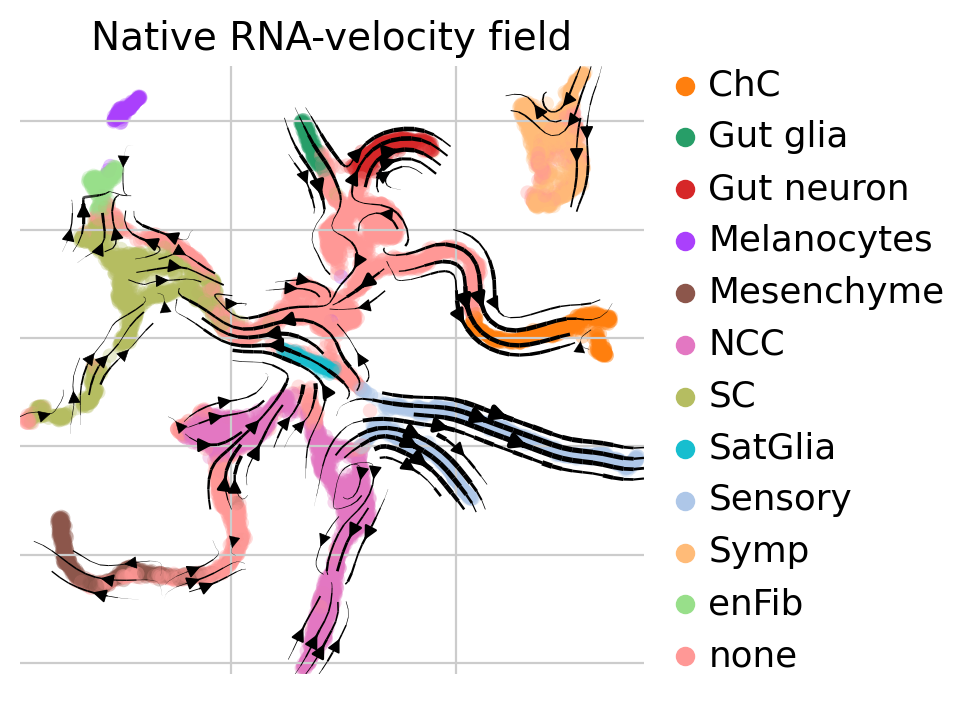

In [5]:
native_color = "assignments" if "assignments" in adata.obs else "cell_type_new"
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    color=native_color,
    legend_loc="right margin",
    title="Native RNA-velocity field",
)

## 4. Define the supervised furcation and future-fate settings


In [6]:
ROOT = "Common Progenitor"
FATES = ["Gut", "Gut neuron", "ChC"]
OBS_KEY = "cell_type_new"
ORDERING_KEY = "inverse_cytotrace_pseudotime"
TARGET_FATE = "ChC"
FUTURE_OPTIONS = {
    "effective_horizon": 64,
    "anchor_quantile": 0.90,
    "min_anchor_cells": 10,
    "progression_scale": "rank",
}

## 5. Real-study metadata or controlled demonstration design

A scientific analysis must use genuine biological replicates. The controlled
demonstration balances state and ordering composition across pseudo-replicates,
then tilts root-cell transition probabilities toward destinations with higher
baseline target-fate probability. The transition support is unchanged and every
row remains normalized.


The controlled perturbation is intentionally strong enough to recover the
predeclared ChC **Conditional Fate Affinity** effect with replicate-level
inference. It validates the software workflow only; it is not a biological
treatment model.


In [7]:
def assign_stratified_demo_design(
    adata,
    *,
    annotation_key,
    ordering_key,
    conditions,
    replicates_per_condition,
    condition_key="condition",
    replicate_key="sample_id",
    n_ordering_bins=5,
    random_state=0,
):
    """Create balanced technical pseudo-conditions within state/order strata.

    This helper is for tutorial validation only. It must not replace genuine
    biological condition and replicate metadata in a scientific analysis.
    """
    annotations = adata.obs[annotation_key].astype(str)
    ordering = pd.to_numeric(adata.obs[ordering_key], errors="coerce")
    if ordering.isna().any():
        raise ValueError(f"{ordering_key!r} contains missing or nonnumeric values.")
    strata = pd.Series(index=adata.obs_names, dtype=object)
    for annotation, indices in annotations.groupby(annotations).groups.items():
        indices = pd.Index(indices)
        values = ordering.loc[indices]
        n_bins = min(n_ordering_bins, len(indices), int(values.nunique()))
        if n_bins <= 1:
            bins = pd.Series("0", index=indices)
        else:
            bins = pd.qcut(
                values.rank(method="first"),
                q=n_bins,
                labels=False,
                duplicates="drop",
            ).astype(str)
        strata.loc[indices] = str(annotation) + "::" + bins

    conditions = tuple(map(str, conditions))
    combinations = [
        (condition, f"{condition}_R{replicate + 1}")
        for condition in conditions
        for replicate in range(int(replicates_per_condition))
    ]
    rng = np.random.default_rng(random_state)
    assigned_condition = pd.Series(index=adata.obs_names, dtype=object)
    assigned_replicate = pd.Series(index=adata.obs_names, dtype=object)
    for _, indices in strata.groupby(strata, sort=True).groups.items():
        indices = np.asarray(list(indices), dtype=object)
        rng.shuffle(indices)
        for position, index in enumerate(indices):
            condition, replicate = combinations[position % len(combinations)]
            assigned_condition.loc[index] = condition
            assigned_replicate.loc[index] = replicate

    adata.obs[condition_key] = pd.Categorical(
        assigned_condition,
        categories=list(conditions),
        ordered=True,
    )
    adata.obs[replicate_key] = pd.Categorical(assigned_replicate)
    return pd.DataFrame(
        {
            "stratum": strata.astype(str),
            condition_key: adata.obs[condition_key].astype(str),
            replicate_key: adata.obs[replicate_key].astype(str),
        },
        index=adata.obs_names,
    )


def target_destination_score(adata, result, *, annotation_key, target_fate):
    """Map baseline Conditional Fate Affinity to every destination cell."""
    score = np.zeros(adata.n_obs, dtype=float)
    selected_indices = adata.obs_names.get_indexer(result.cell_ids)
    if np.any(selected_indices < 0):
        raise ValueError("Result cells could not be aligned to AnnData.")
    fate_index = result.fate_names.index(str(target_fate))
    score[selected_indices] = result.conditional_fate_affinity[:, fate_index]
    terminal = adata.obs[annotation_key].astype(str).eq(str(target_fate)).to_numpy()
    score[terminal] = 1.0
    return np.clip(score, 0.0, 1.0)


def reweight_root_transitions(
    transition_matrix,
    *,
    source_mask,
    condition_labels,
    replicate_labels,
    destination_score,
    log_shift_by_condition,
    replicate_shift_sd=0.08,
    random_state=0,
):
    """Inject a controlled condition effect without changing graph support.

    Outgoing root-cell transition probabilities are tilted toward destinations
    with high baseline target-fate probability and then renormalized. This is a
    software-validation perturbation, not a model for a particular experiment.
    """
    normalized = scCS.canonicalize_transition_matrix(transition_matrix)
    transition = normalized.matrix.tocsr(copy=True)
    source_mask = np.asarray(source_mask, dtype=bool)
    conditions = np.asarray(condition_labels, dtype=str)
    replicates = np.asarray(replicate_labels, dtype=str)
    destination_score = np.asarray(destination_score, dtype=float)
    if source_mask.shape != (transition.shape[0],):
        raise ValueError("source_mask must align to transition rows.")
    if destination_score.shape != (transition.shape[0],):
        raise ValueError("destination_score must align to transition columns.")

    rng = np.random.default_rng(random_state)
    replicate_effect = {
        replicate: float(rng.normal(0.0, replicate_shift_sd)) for replicate in np.unique(replicates)
    }
    affected = np.zeros(transition.shape[0], dtype=bool)
    for row in np.flatnonzero(source_mask):
        condition = conditions[row]
        if condition not in log_shift_by_condition:
            raise KeyError(f"Missing log shift for condition {condition!r}.")
        start, stop = transition.indptr[row], transition.indptr[row + 1]
        columns = transition.indices[start:stop]
        if len(columns) == 0:
            continue
        shift = float(log_shift_by_condition[condition]) + replicate_effect[replicates[row]]
        multipliers = np.exp(shift * destination_score[columns])
        if np.max(np.abs(multipliers - 1.0)) > 1e-12:
            affected[row] = True
        transition.data[start:stop] *= multipliers
        row_sum = float(transition.data[start:stop].sum())
        if row_sum > 0:
            transition.data[start:stop] /= row_sum
    audit = {
        "affected_root_fraction": float(np.mean(affected[source_mask])),
        "max_row_sum_error": float(
            np.max(np.abs(np.asarray(transition.sum(axis=1)).ravel() - 1.0))
        ),
        "replicate_shift_sd": float(replicate_shift_sd),
        "log_shift_by_condition": dict(log_shift_by_condition),
    }
    return transition, audit

In [8]:
original_transition = scCS.get_scvelo_transition_matrix(adata)

if DEMO_MODE:
    assignments = assign_stratified_demo_design(
        adata,
        annotation_key=OBS_KEY,
        ordering_key=ORDERING_KEY,
        conditions=CONDITIONS,
        replicates_per_condition=REPLICATES_PER_CONDITION,
        condition_key=CONDITION_KEY,
        replicate_key=REPLICATE_KEY,
        random_state=SEED,
    )
    baseline_scorer = scCS.SingleScorer(
        adata,
        root=ROOT,
        branches=FATES,
        obs_key=OBS_KEY,
    )
    baseline_scorer.build_embedding(ordering_metric=ORDERING_KEY, verbose=False)
    baseline_scorer.fit(
        transition_matrix=original_transition,
        scoring_mode="future_fate",
        future_fate_options=FUTURE_OPTIONS,
        verbose=False,
    )
    baseline_result = baseline_scorer.score(write_to_adata=False, verbose=False)
    destination_score = target_destination_score(
        adata,
        baseline_result,
        annotation_key=OBS_KEY,
        target_fate=TARGET_FATE,
    )
    labels = adata.obs[OBS_KEY].astype(str)
    root_labels = {ROOT} if isinstance(ROOT, str) else set(ROOT)
    root_mask_full = labels.isin(root_labels).to_numpy()
    analysis_transition, perturbation_audit = reweight_root_transitions(
        original_transition,
        source_mask=root_mask_full,
        condition_labels=adata.obs[CONDITION_KEY].astype(str).to_numpy(),
        replicate_labels=adata.obs[REPLICATE_KEY].astype(str).to_numpy(),
        destination_score=destination_score,
        log_shift_by_condition={"control": 0.0, "treated": 1.75},
        replicate_shift_sd=0.03,
        random_state=SEED + 1,
    )
    display(pd.Series(perturbation_audit, name="value").to_frame())
else:
    required = {CONDITION_KEY, REPLICATE_KEY}
    missing = sorted(required - set(adata.obs.columns))
    if missing:
        raise KeyError(f"Missing real-study metadata columns: {missing}")
    analysis_transition = original_transition

design_balance = (
    adata.obs.groupby([CONDITION_KEY, REPLICATE_KEY], observed=True)
    .size()
    .rename("n_cells")
    .reset_index()
)
display(design_balance)

,value
affected_root_fraction,1.0
max_row_sum_error,0.0
replicate_shift_sd,0.03
log_shift_by_condition,"{'control': 0.0, 'treated': 1.75}"


,condition,sample_id,n_cells
0,control,control_R1,890
1,control,control_R2,890
2,control,control_R3,887
3,control,control_R4,885
4,control,control_R5,885
5,treated,treated_R1,880
6,treated,treated_R2,880
7,treated,treated_R3,880
8,treated,treated_R4,879
9,treated,treated_R5,865


## 6. Construct PairScorer, preflight, and fit one pooled model


In [9]:
pair = scCS.PairScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key=OBS_KEY,
    condition_obs_key=CONDITION_KEY,
    replicate_obs_key=REPLICATE_KEY,
    condition_order=list(CONDITIONS),
)
preflight = pair.preflight(ordering_metric=ORDERING_KEY, check_velocity=True)
preflight.display()
preflight.raise_for_errors()
pair.build_embedding(ordering_metric=ORDERING_KEY)
pair.fit(
    transition_matrix=analysis_transition,
    scoring_mode="future_fate",
    transition_scope="pooled",
    future_fate_options=FUTURE_OPTIONS,
)
results = pair.score_all_conditions(
    population="root",
    min_cells=20,
    min_replicates=4,
)
replicate_table = pair.replicate_table(results)
display(replicate_table)
replicate_table.to_csv(OUTPUT_DIR / "replicate_outcomes.csv", index=False)

,level,code,message,value
0,info,furcation_valid,Root and terminal annotations are valid.,1976.000000
1,info,root_cells,Root population contains 675 cells.,675.000000
2,info,terminal_Gut,Terminal 'Gut' contains 245 cells.,245.000000
3,info,terminal_Gut neuron,Terminal 'Gut neuron' contains 294 cells.,294.000000
4,info,terminal_ChC,Terminal 'ChC' contains 762 cells.,762.000000
5,info,ordering_valid,Ordering metric is finite and non-constant amo...,1.000000
6,info,ordering_resolution,Root ordering has 337 unique values across 675...,0.499259
7,info,velocity_available,Velocity information is available.,NaN
8,info,condition_control_cells,Condition 'control' contains 4437 cells.,4437.000000
9,info,condition_treated_cells,Condition 'treated' contains 4384 cells.,4384.000000


[scCS] Scientific star built for 1976 cells in 3 dimensions.
       Root radial clipping: 0.050 low / 0.050 high
       Terminal scientific coordinates: fixed equal-radius simplex vertices (radius=1.000).
scCS FutureFateScoreResult
  Furcation: Common Progenitor -> ['Gut', 'Gut neuron', 'ChC']
  Effective horizon: 64 (gamma=0.984615)
  Cells: 1976 selected; 675 root
  Root affinity coverage: 1.000
  Root mean future-fate reach: 0.192
  Root mean future-fate entropy: 0.771
  Root mean future-fate specificity: 0.229
  Root mean reach-supported specificity: 0.048
  Root mean unresolved probability: 0.808
  Root mean signed progression: 0.014
  Root future-fate composition: Gut=0.102, Gut neuron=0.259, ChC=0.638
  Solver: direct; iterations=1; residual=2.912e-15
[scCS] 'control': 350 root cells; 5 replicates.
[scCS] 'treated': 325 root cells; 5 replicates.


,condition,replicate_id,replicate_label,n_cells,n_valid_projection,mean_commitment_strength,mean_directional_entropy,mean_commitment_entropy,mean_directional_specificity,mean_nearest_fate_angle_degrees,...,commitment_composition::Gut neuron,mean_commitment_contribution::ChC,directional_affinity::ChC,commitment_composition::ChC,pairwise_log_commitment_ratio::Gut::Gut neuron,pairwise_log_commitment_ratio::Gut neuron::Gut,pairwise_log_commitment_ratio::Gut::ChC,pairwise_log_commitment_ratio::ChC::Gut,pairwise_log_commitment_ratio::Gut neuron::ChC,pairwise_log_commitment_ratio::ChC::Gut neuron
0,control,control::control_R1,control_R1,70,70,0.176655,0.786697,0.991308,0.213303,NaN,...,0.271884,0.109755,0.630331,0.621293,-0.934201,0.934201,-1.760627,1.760627,-0.826426,0.826426
1,control,control::control_R2,control_R2,70,70,0.189474,0.776307,0.988802,0.223693,NaN,...,0.274135,0.117986,0.635219,0.622706,-0.977346,0.977346,-1.797798,1.797798,-0.820453,0.820453
2,control,control::control_R3,control_R3,70,70,0.187954,0.777368,0.990300,0.222632,NaN,...,0.269429,0.116390,0.628179,0.619247,-0.883859,0.883859,-1.716058,1.716058,-0.832199,0.832199
3,control,control::control_R4,control_R4,70,70,0.172603,0.780164,0.991348,0.219836,NaN,...,0.256730,0.109146,0.638000,0.632352,-0.839234,0.839234,-1.740654,1.740654,-0.901420,0.901420
4,control,control::control_R5,control_R5,70,70,0.191395,0.784171,0.989062,0.215829,NaN,...,0.285842,0.116013,0.620548,0.606141,-0.973143,0.973143,-1.724817,1.724817,-0.751674,0.751674
5,treated,treated::treated_R1,treated_R1,65,65,0.201000,0.768534,0.987081,0.231466,NaN,...,0.265825,0.126278,0.638268,0.628248,-0.920085,0.920085,-1.780182,1.780182,-0.860097,0.860097
6,treated,treated::treated_R2,treated_R2,65,65,0.191605,0.763324,0.988597,0.236676,NaN,...,0.231375,0.127585,0.655481,0.665876,-0.811753,0.811753,-1.868816,1.868816,-1.057064,1.057064
7,treated,treated::treated_R3,treated_R3,65,65,0.204845,0.757471,0.984333,0.242529,NaN,...,0.239673,0.136032,0.654548,0.664074,-0.912297,0.912297,-1.931413,1.931413,-1.019117,1.019117
8,treated,treated::treated_R4,treated_R4,65,65,0.206149,0.745743,0.984952,0.254257,NaN,...,0.235810,0.138920,0.664893,0.673884,-0.959821,0.959821,-2.009851,2.009851,-1.050030,1.050030
9,treated,treated::treated_R5,treated_R5,65,65,0.204758,0.767782,0.985931,0.232218,NaN,...,0.261759,0.132966,0.641974,0.649381,-1.080363,1.080363,-1.988958,1.988958,-0.908594,0.908594


## 7. Descriptive condition summaries before hypothesis testing


In [10]:
summary_rows = []
for condition, condition_result in results.items():
    population = condition_result.population_summary
    row = {
        "condition": condition,
        "n_cells": condition_result.n_cells,
        "n_replicates": condition_result.n_replicates,
        "mean_future_fate_reach": np.nanmean(condition_result.commitment_strength),
        "mean_future_fate_entropy": np.nanmean(condition_result.directional_entropy),
        "mean_future_fate_specificity": np.nanmean(condition_result.directional_specificity),
        "mean_reach_supported_specificity": np.nanmean(condition_result.specific_commitment),
        "mean_signed_progression": np.nanmean(condition_result.progression_velocity),
        "mean_selected_path_coverage": np.nanmean(condition_result.transition_coverage),
        "population_balance_entropy": population.population_balance_entropy,
        "total_future_fate_mass": population.total_mass,
    }
    for fate_index, fate in enumerate(condition_result.fate_names):
        row[f"mean_affinity_{fate}"] = np.nanmean(
            condition_result.directional_affinity[:, fate_index]
        )
        row[f"mean_contribution_{fate}"] = np.nanmean(
            condition_result.commitment_contribution[:, fate_index]
        )
    summary_rows.append(row)
condition_summary = pd.DataFrame(summary_rows)
display(condition_summary)
condition_summary.to_csv(OUTPUT_DIR / "condition_summary.csv", index=False)

,condition,n_cells,n_replicates,mean_future_fate_reach,mean_future_fate_entropy,mean_future_fate_specificity,mean_reach_supported_specificity,mean_signed_progression,mean_selected_path_coverage,population_balance_entropy,total_future_fate_mass,mean_affinity_Gut,mean_contribution_Gut,mean_affinity_Gut neuron,mean_contribution_Gut neuron,mean_affinity_ChC,mean_contribution_ChC
0,control,350,5,0.183616,0.780941,0.219059,0.043191,0.018771,0.865448,0.810857,64.265724,0.119346,0.019832,0.250199,0.049927,0.630456,0.113858
1,treated,325,5,0.201671,0.760571,0.239429,0.053402,0.008932,0.920881,0.771606,65.543201,0.109272,0.019501,0.239695,0.049814,0.651033,0.132356


## 8. Primary target-fate comparison with permutation and hierarchical bootstrap


In [11]:
target_affinity_stats = pair.compare_conditions(
    results,
    condition_a=CONDITIONS[0],
    condition_b=CONDITIONS[1],
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    n_permutations=9999,
    n_bootstrap=2000,
    confidence_level=0.95,
    random_state=SEED,
)
target_contribution_stats = pair.compare_conditions(
    results,
    metric="future_fate_contribution",
    fate=TARGET_FATE,
    n_permutations=9999,
    n_bootstrap=2000,
    random_state=SEED + 1,
)
display(target_affinity_stats)
display(target_contribution_stats)

[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_affinity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='mean_commitment_contribution'.


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward ChC,ChC,None,None,control,treated,0.630456,0.651033,...,exact,252,5,5,0.007937,0.006361,0.035996,0.95,2000,True


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward ChC,ChC,None,None,control,treated,0.113858,0.132356,...,exact,252,5,5,0.007937,0.008251,0.028724,0.95,2000,True


## 9. Full fate-wise and scalar outcome battery


In [12]:
fate_affinity_stats = pair.compare_conditions(
    results,
    metric="future_fate_affinity",
    n_permutations=9999,
    n_bootstrap=1000,
    random_state=SEED + 2,
)
fate_contribution_stats = pair.compare_conditions(
    results,
    metric="future_fate_contribution",
    n_permutations=9999,
    n_bootstrap=1000,
    random_state=SEED + 3,
)
scalar_tables = []
for offset, metric in enumerate(
    (
        "future_fate_reach",
        "future_fate_specificity",
        "reach_supported_specificity",
        "future_fate_entropy",
        "signed_progression",
        "selected_path_coverage",
    )
):
    table = pair.compare_conditions(
        results,
        metric=metric,
        n_permutations=9999,
        n_bootstrap=1000,
        random_state=SEED + 10 + offset,
    )
    scalar_tables.append(table)
scalar_stats = pd.concat(scalar_tables, ignore_index=True)
display(fate_affinity_stats)
display(fate_contribution_stats)
display(scalar_stats)
fate_affinity_stats.to_csv(OUTPUT_DIR / "fate_affinity_statistics.csv", index=False)
fate_contribution_stats.to_csv(OUTPUT_DIR / "fate_contribution_statistics.csv", index=False)
scalar_stats.to_csv(OUTPUT_DIR / "scalar_statistics.csv", index=False)

[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_affinity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='mean_commitment_contribution'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='commitment_strength'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_specificity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='specific_commitment'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='directional_entropy'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='progression_velocity'.
[scCS] Pairwise replicate inference: 'treated' - 'control'; metric='transition_coverage'.


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Gut,Gut,None,None,control,treated,0.119346,0.109272,...,exact,252,5,5,0.031746,-0.020438,0.001737,0.95,1000,True
1,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward Gut neuron,Gut neuron,None,None,control,treated,0.250199,0.239695,...,exact,252,5,5,0.087302,-0.024380,0.004957,0.95,1000,True
2,directional_affinity,future_fate_affinity,Conditional Fate Affinity (CFA) toward ChC,ChC,None,None,control,treated,0.630456,0.651033,...,exact,252,5,5,0.023810,0.005667,0.035748,0.95,1000,True


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Gut,Gut,None,None,control,treated,0.019832,0.019501,...,exact,252,5,5,1.00000,-0.002728,0.002086,0.95,1000,True
1,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward Gut neuron,Gut neuron,None,None,control,treated,0.049927,0.049814,...,exact,252,5,5,1.00000,-0.008463,0.007781,0.95,1000,True
2,mean_commitment_contribution,future_fate_contribution,Future-fate contribution toward ChC,ChC,None,None,control,treated,0.113858,0.132356,...,exact,252,5,5,0.02381,0.008398,0.029109,0.95,1000,True


,metric,metric_public,metric_label,fate,fate_a,fate_b,condition_a,condition_b,mean_a,mean_b,...,permutation_method,n_permutations,n_replicates_a,n_replicates_b,pvalue_adj,ci_lower,ci_upper,confidence_level,n_bootstrap,resample_cells_within_replicate
0,commitment_strength,future_fate_reach,Discounted Fate Reach (DFR),None,None,None,control,treated,0.183616,0.201671,...,exact,252,5,5,0.007937,0.002049,0.033361,0.95,1000,True
1,directional_specificity,future_fate_specificity,Future-Fate Specificity (FFS),None,None,None,control,treated,0.219059,0.239429,...,exact,252,5,5,0.007937,0.006673,0.034353,0.95,1000,True
2,specific_commitment,reach_supported_specificity,Resolved Commitment (RC),None,None,None,control,treated,0.043191,0.053402,...,exact,252,5,5,0.007937,0.002938,0.018242,0.95,1000,True
3,directional_entropy,future_fate_entropy,Future-fate entropy,None,None,None,control,treated,0.780941,0.760571,...,exact,252,5,5,0.007937,-0.035602,-0.007976,0.95,1000,True
4,progression_velocity,signed_progression,Signed Ordering Flux (SOF),None,None,None,control,treated,0.018771,0.008932,...,exact,252,5,5,0.079365,-0.036855,0.018660,0.95,1000,True
5,transition_coverage,selected_path_coverage,Selected-path coverage,None,None,None,control,treated,0.865448,0.920881,...,exact,252,5,5,0.015873,0.022302,0.088219,0.95,1000,True


## 10. Replicate-first effect visualizations


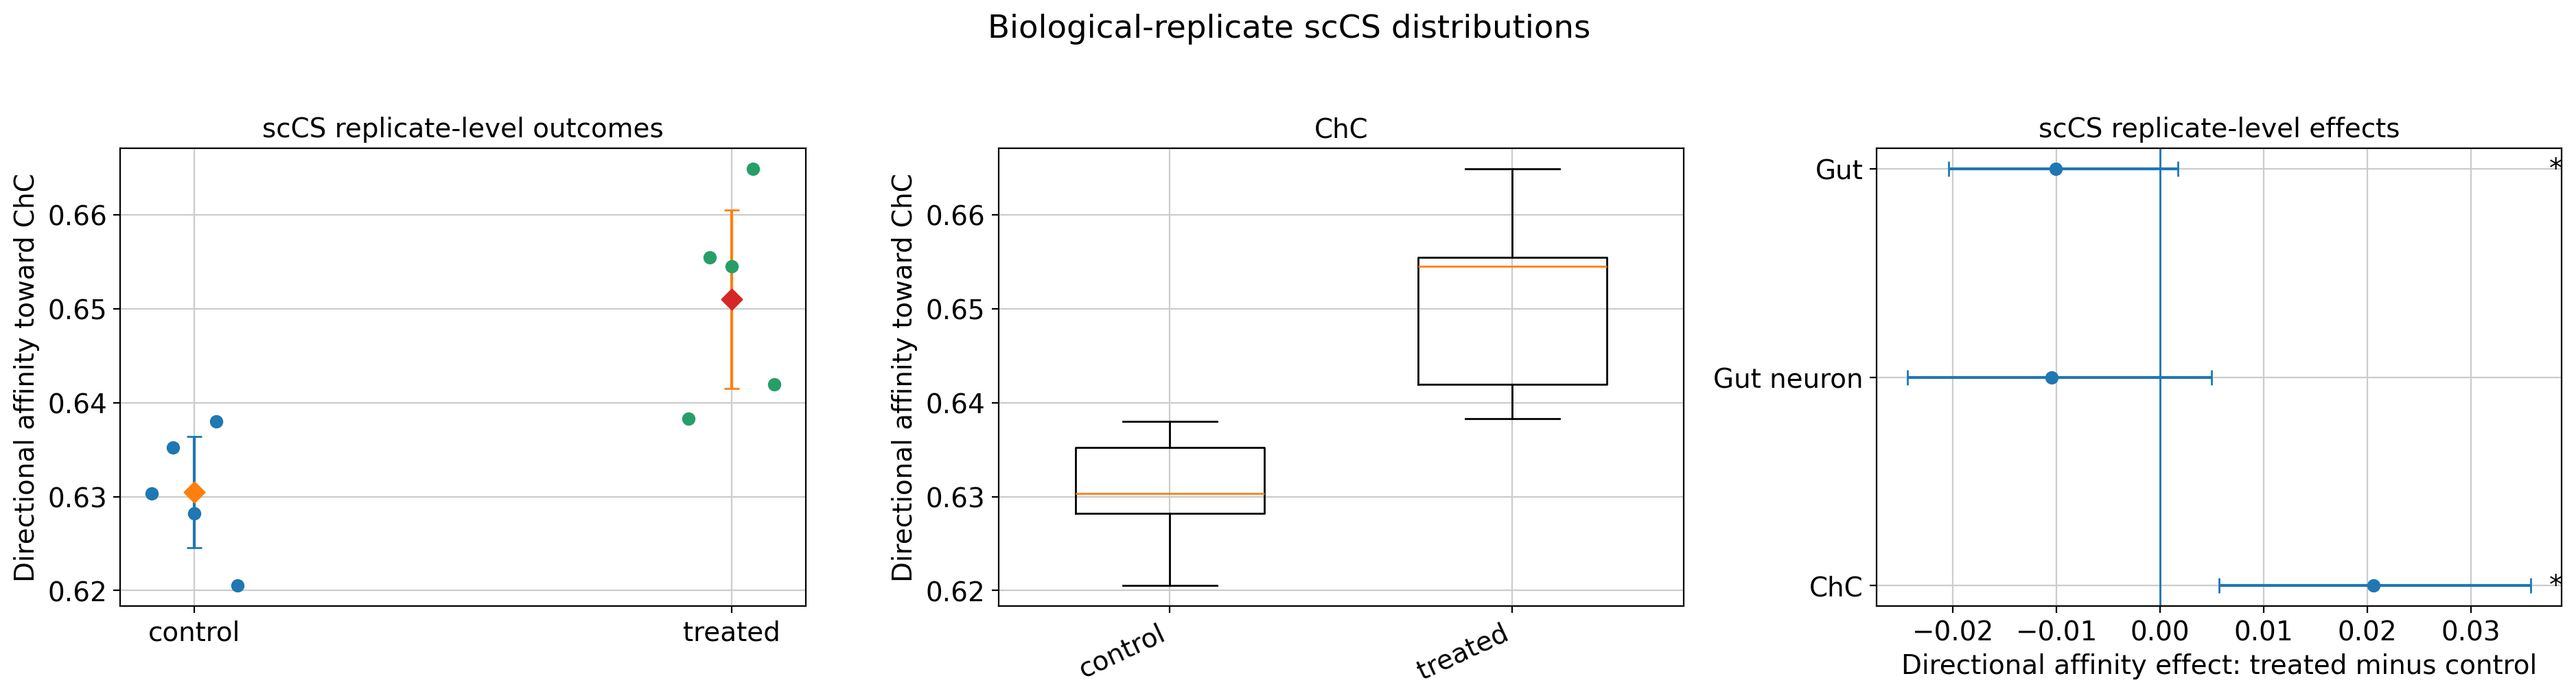

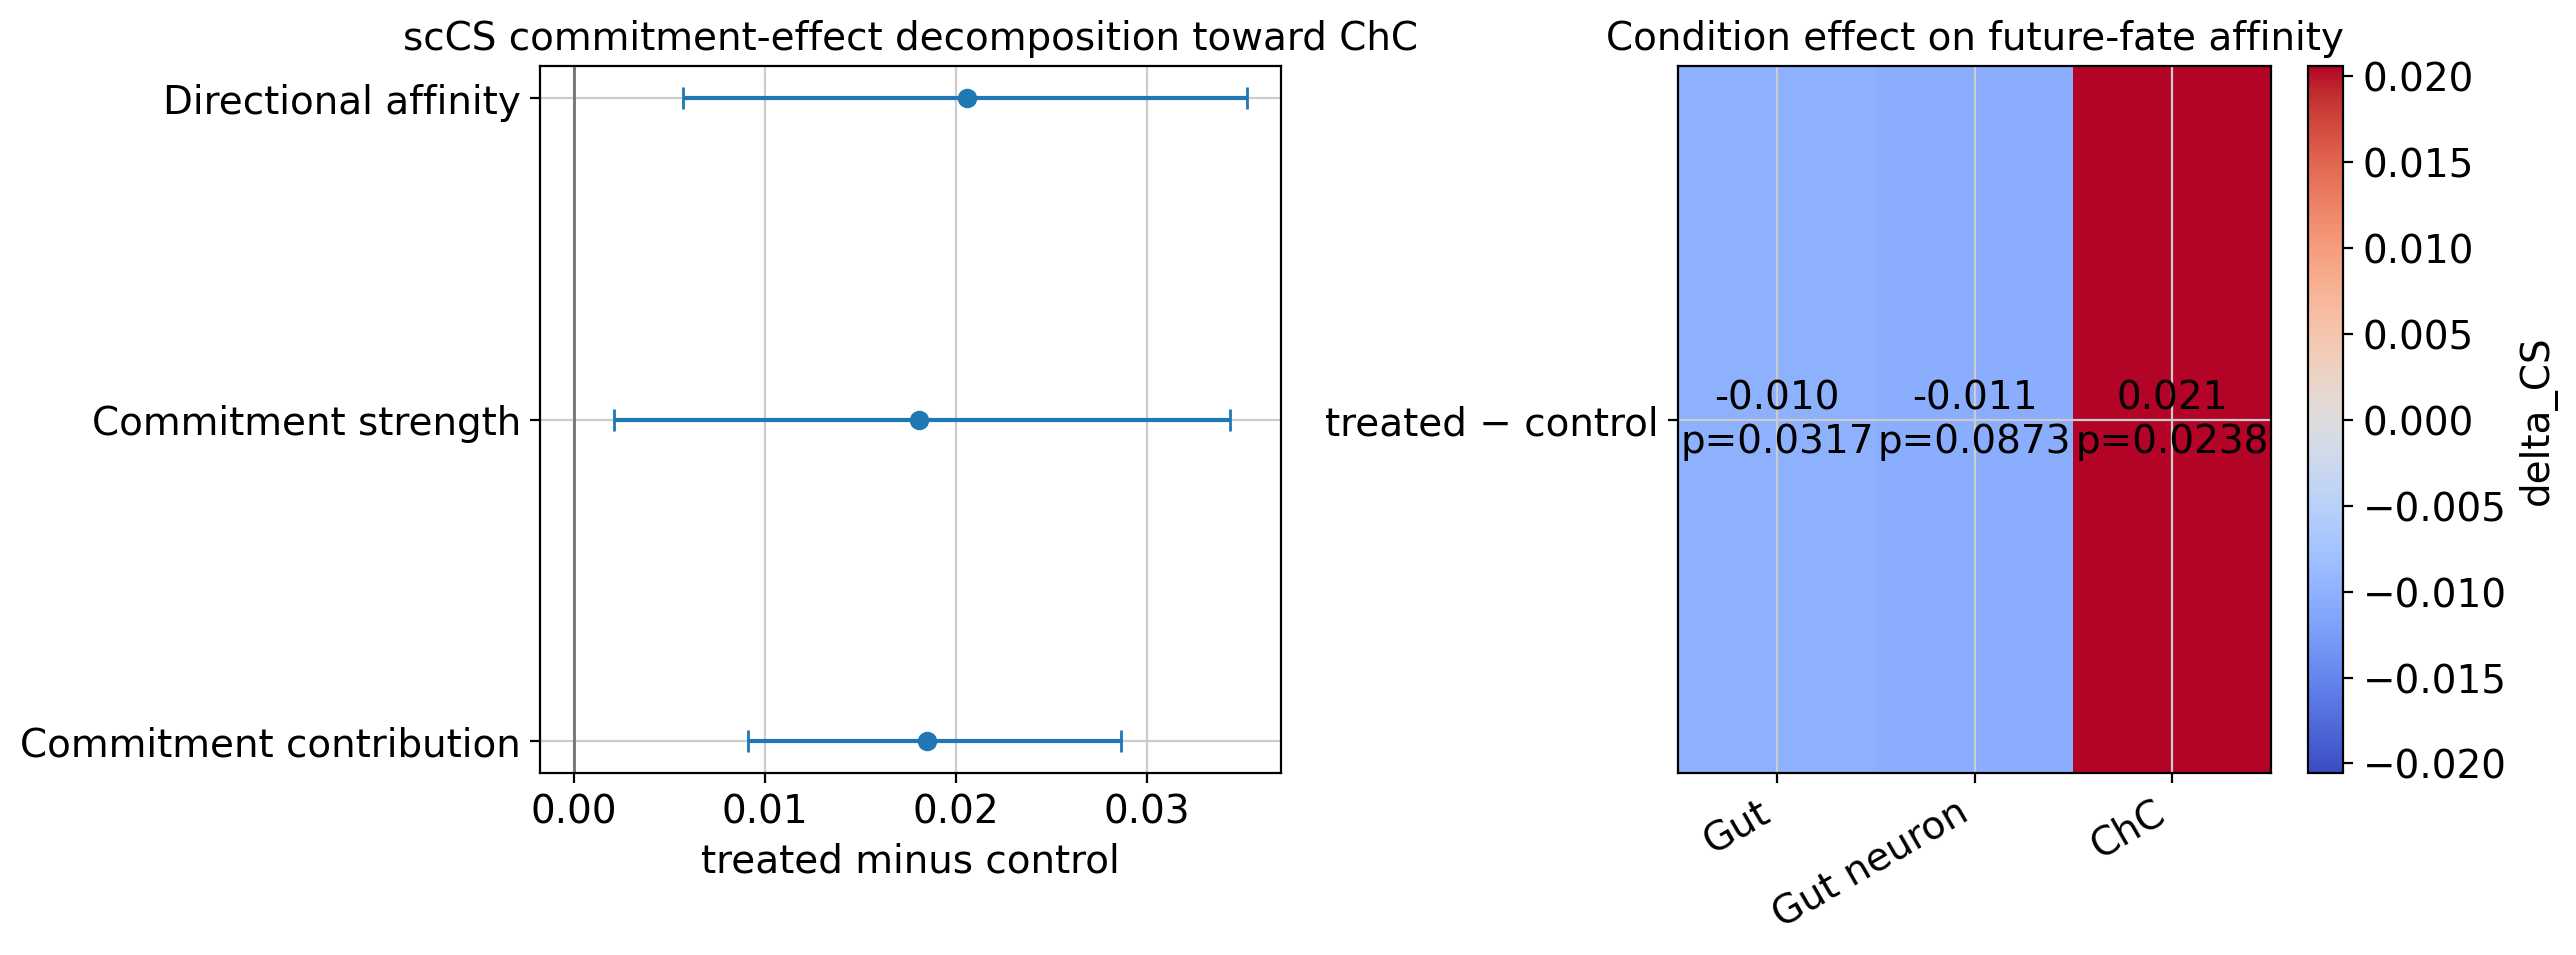

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pair.plot_replicate_outcomes(
    results,
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    ax=axes[0],
)
pair.plot_affinity_distributions(
    results,
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    plot_type="box",
    ax=axes[1],
)
pair.plot_effects(fate_affinity_stats, ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "replicate_effects.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pair.plot_commitment_decomposition(
    results,
    fate=TARGET_FATE,
    n_bootstrap=2000,
    random_state=SEED,
    ax=axes[0],
)
pair.plot_delta_CS_heatmap(
    fate_affinity_stats,
    title="Condition effect on future-fate affinity",
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "effect_decomposition_and_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Condition-specific star grids


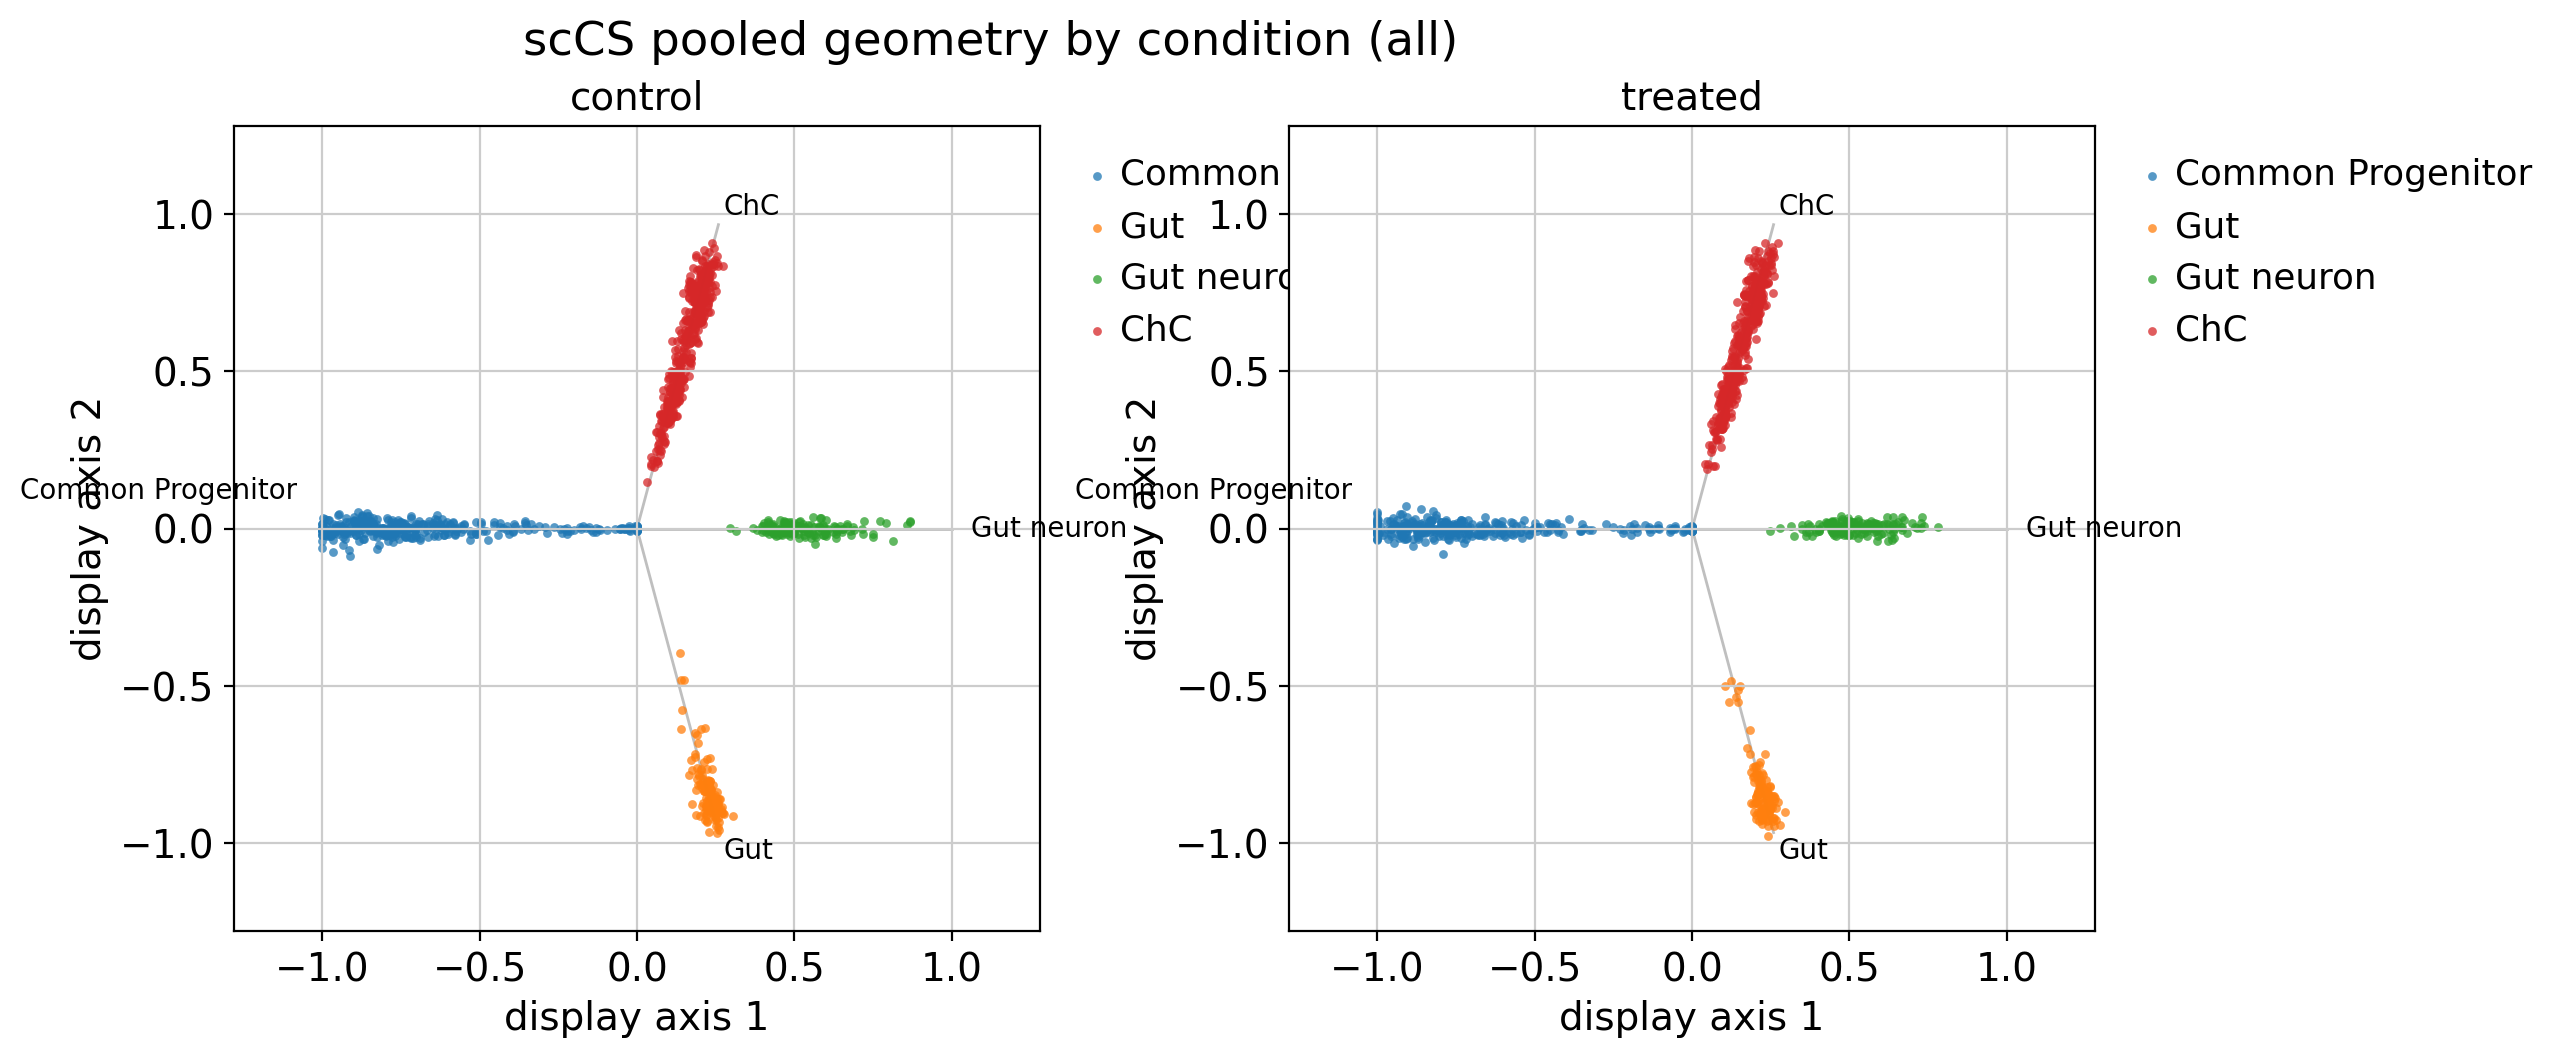

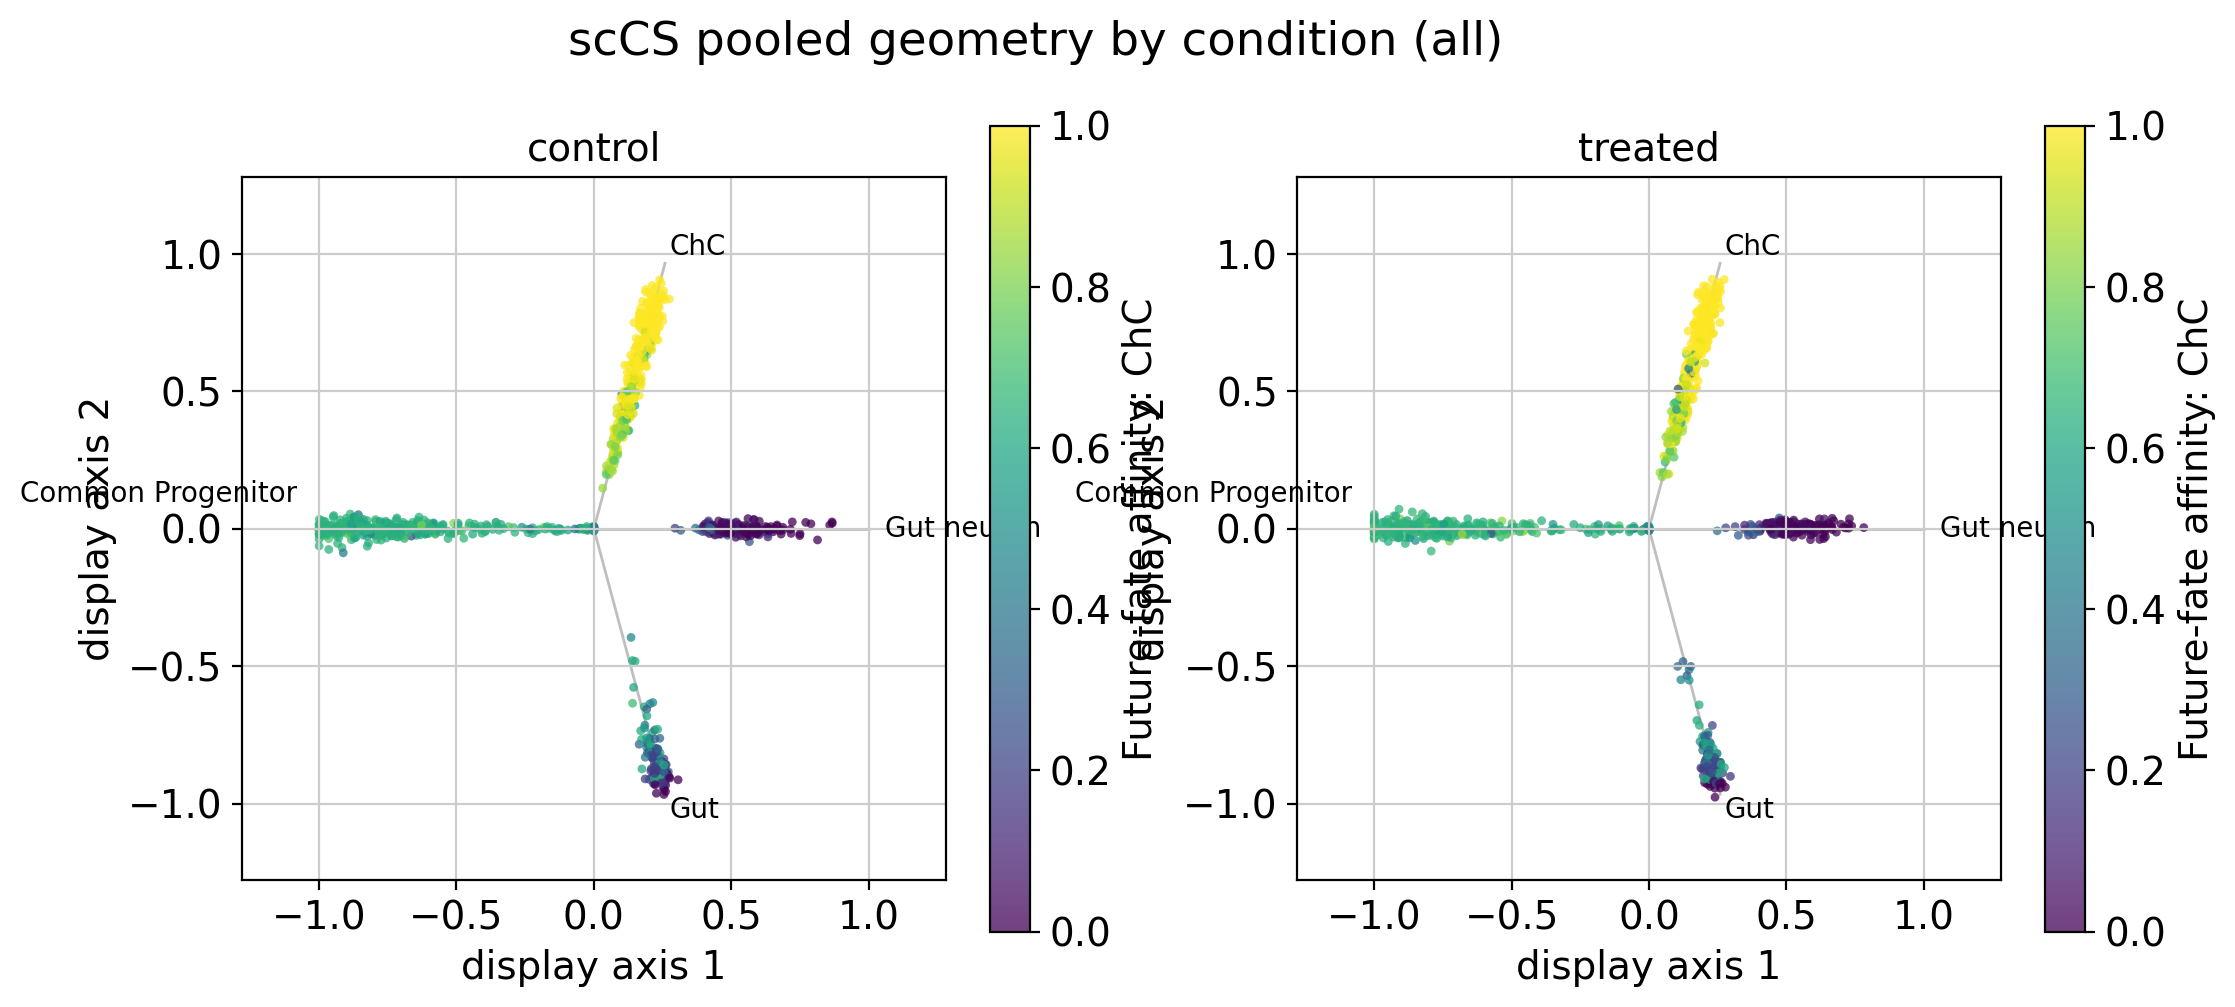

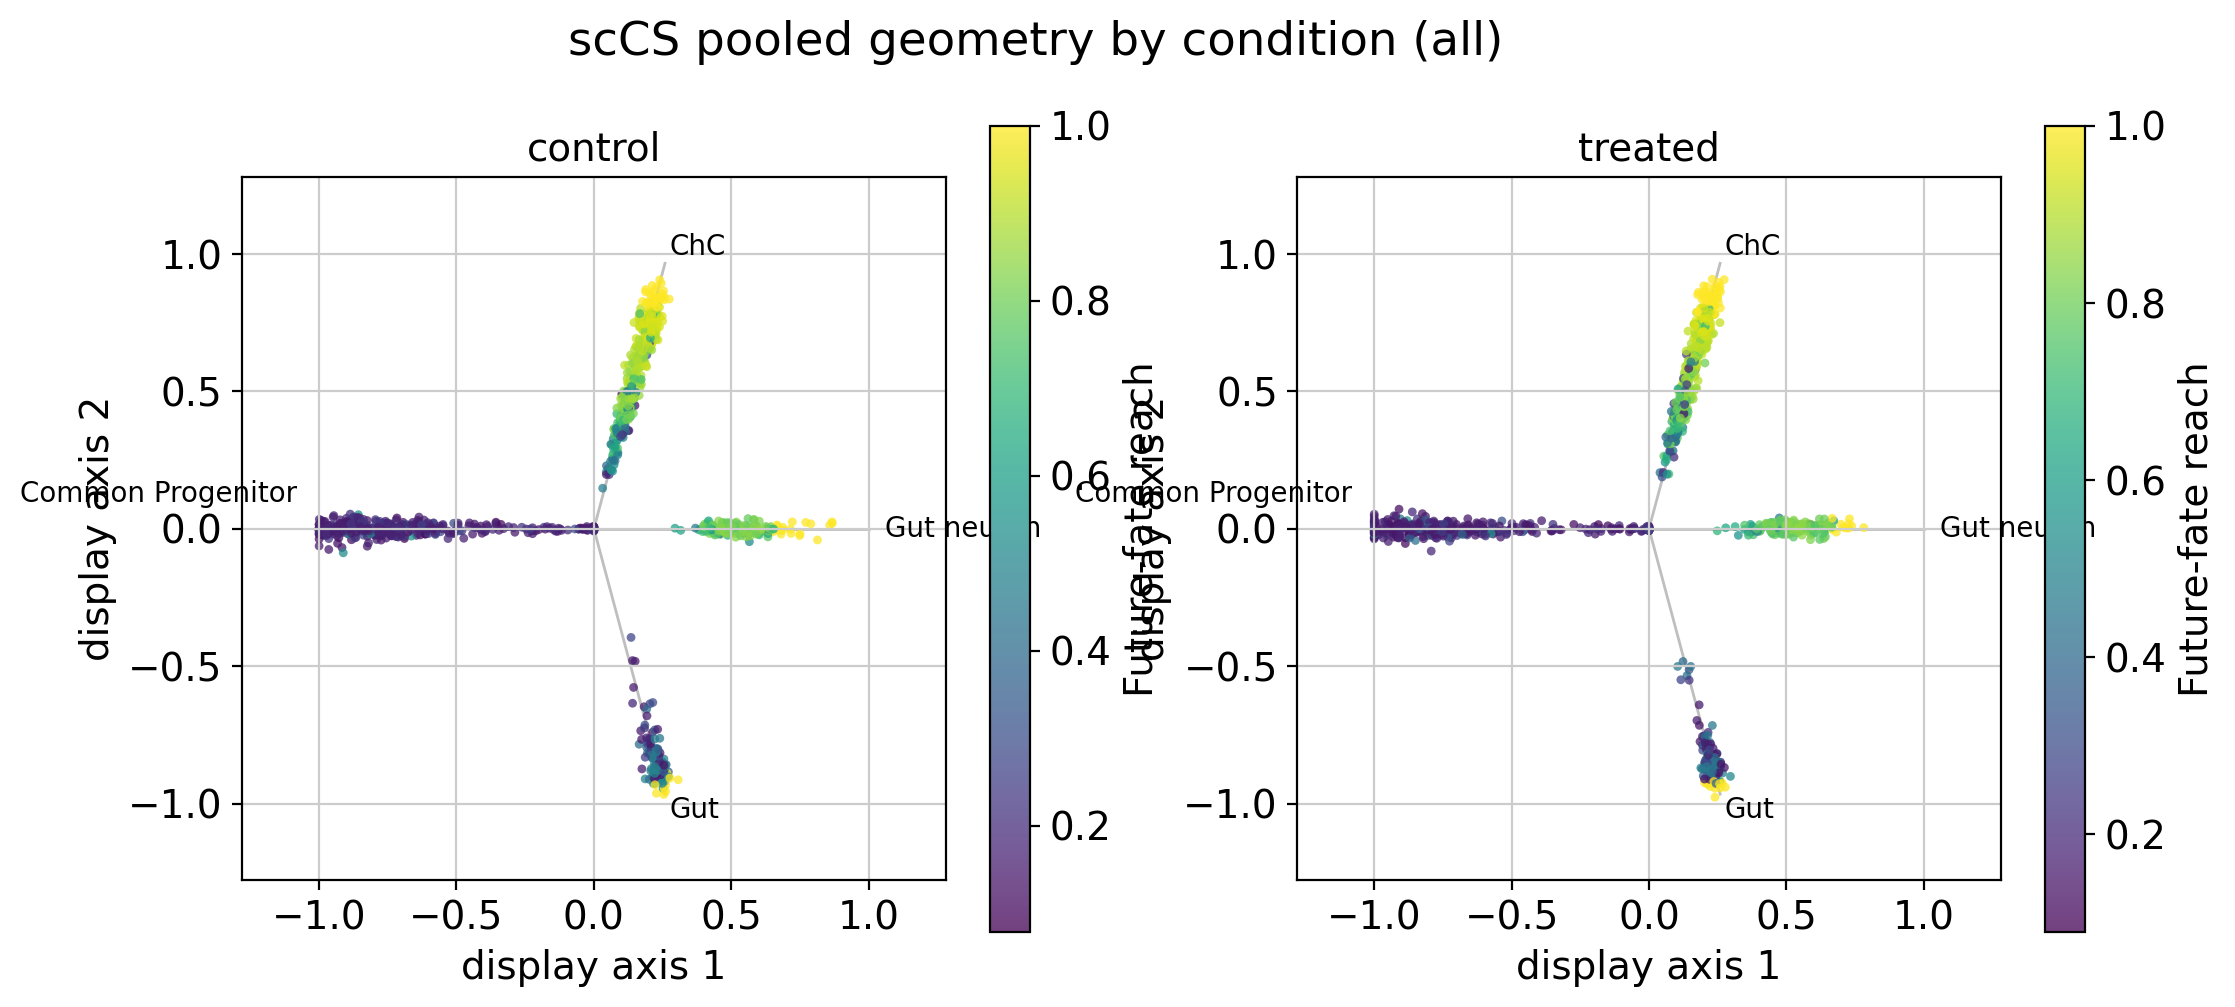

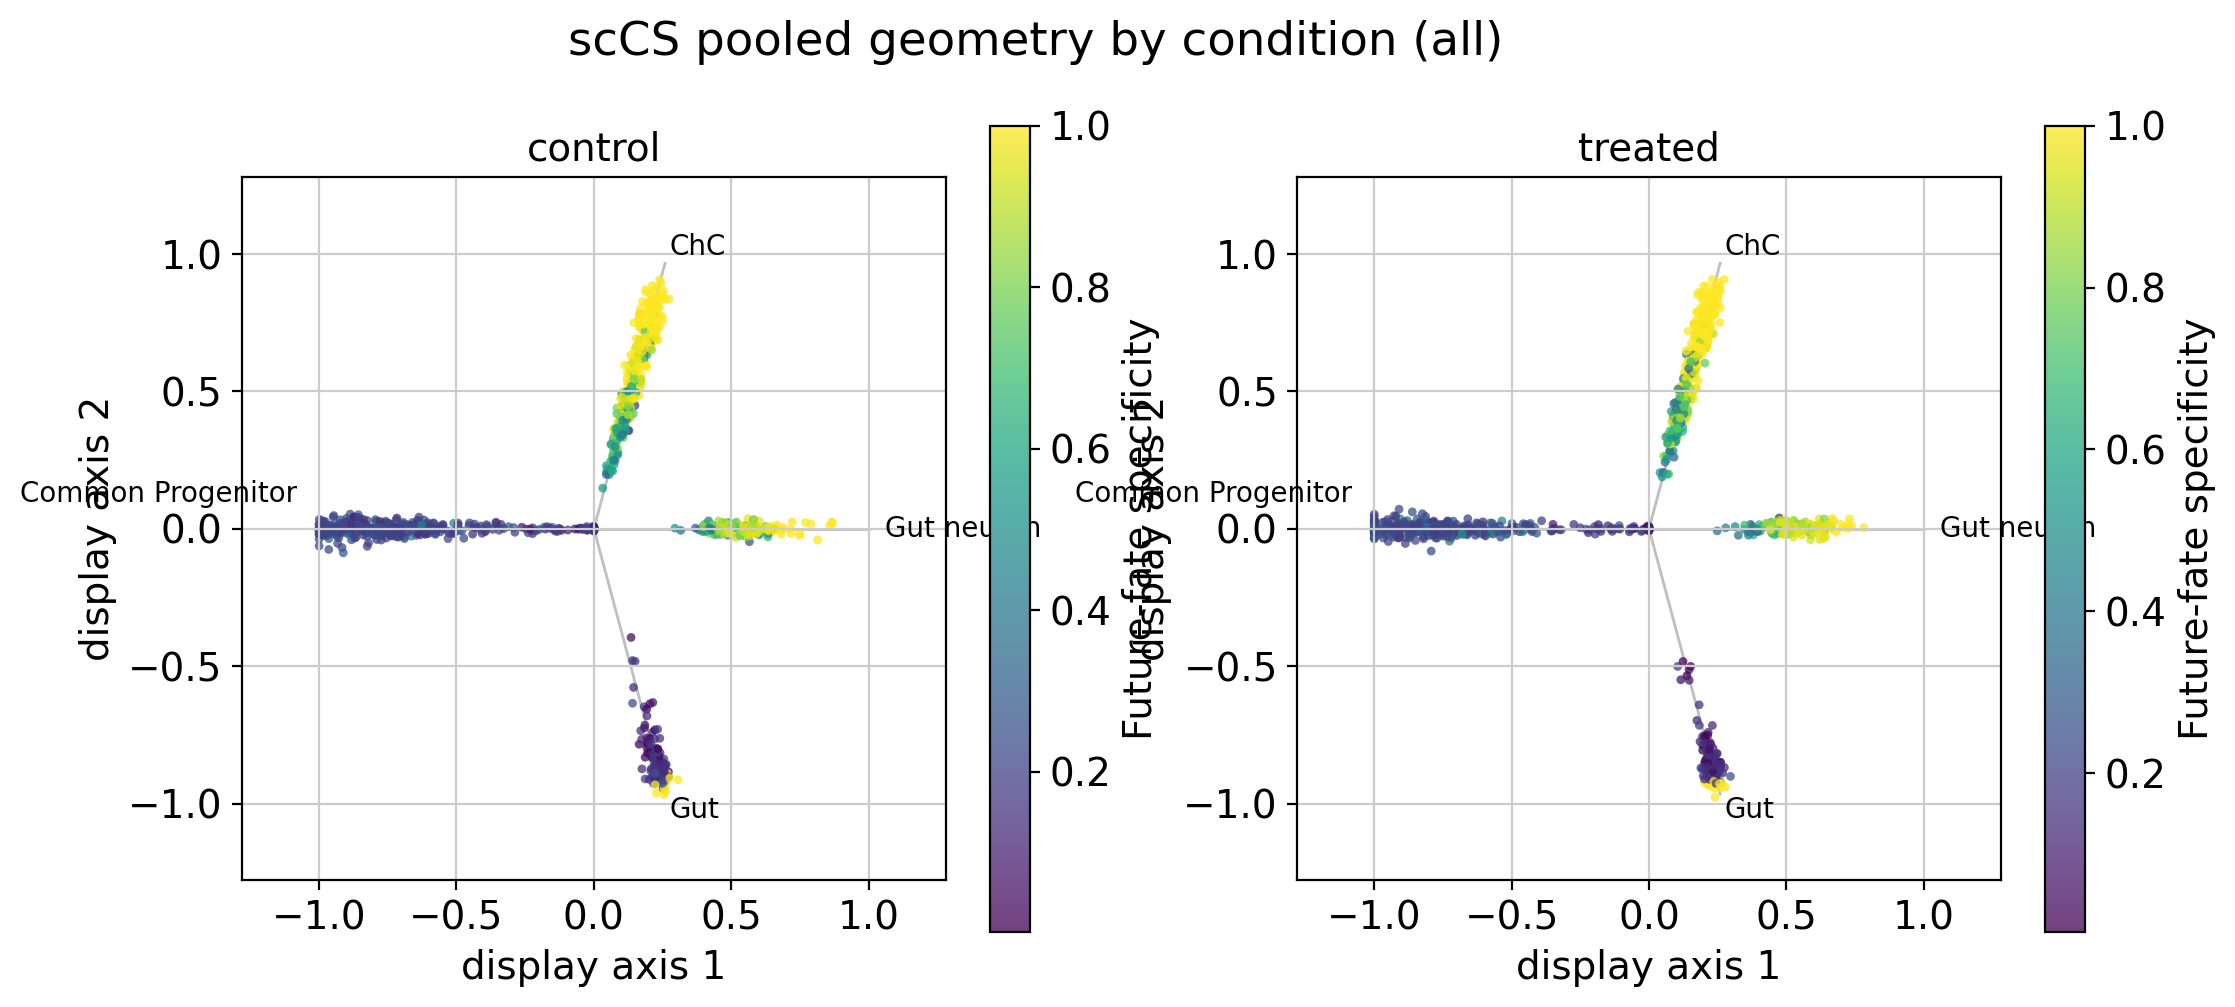

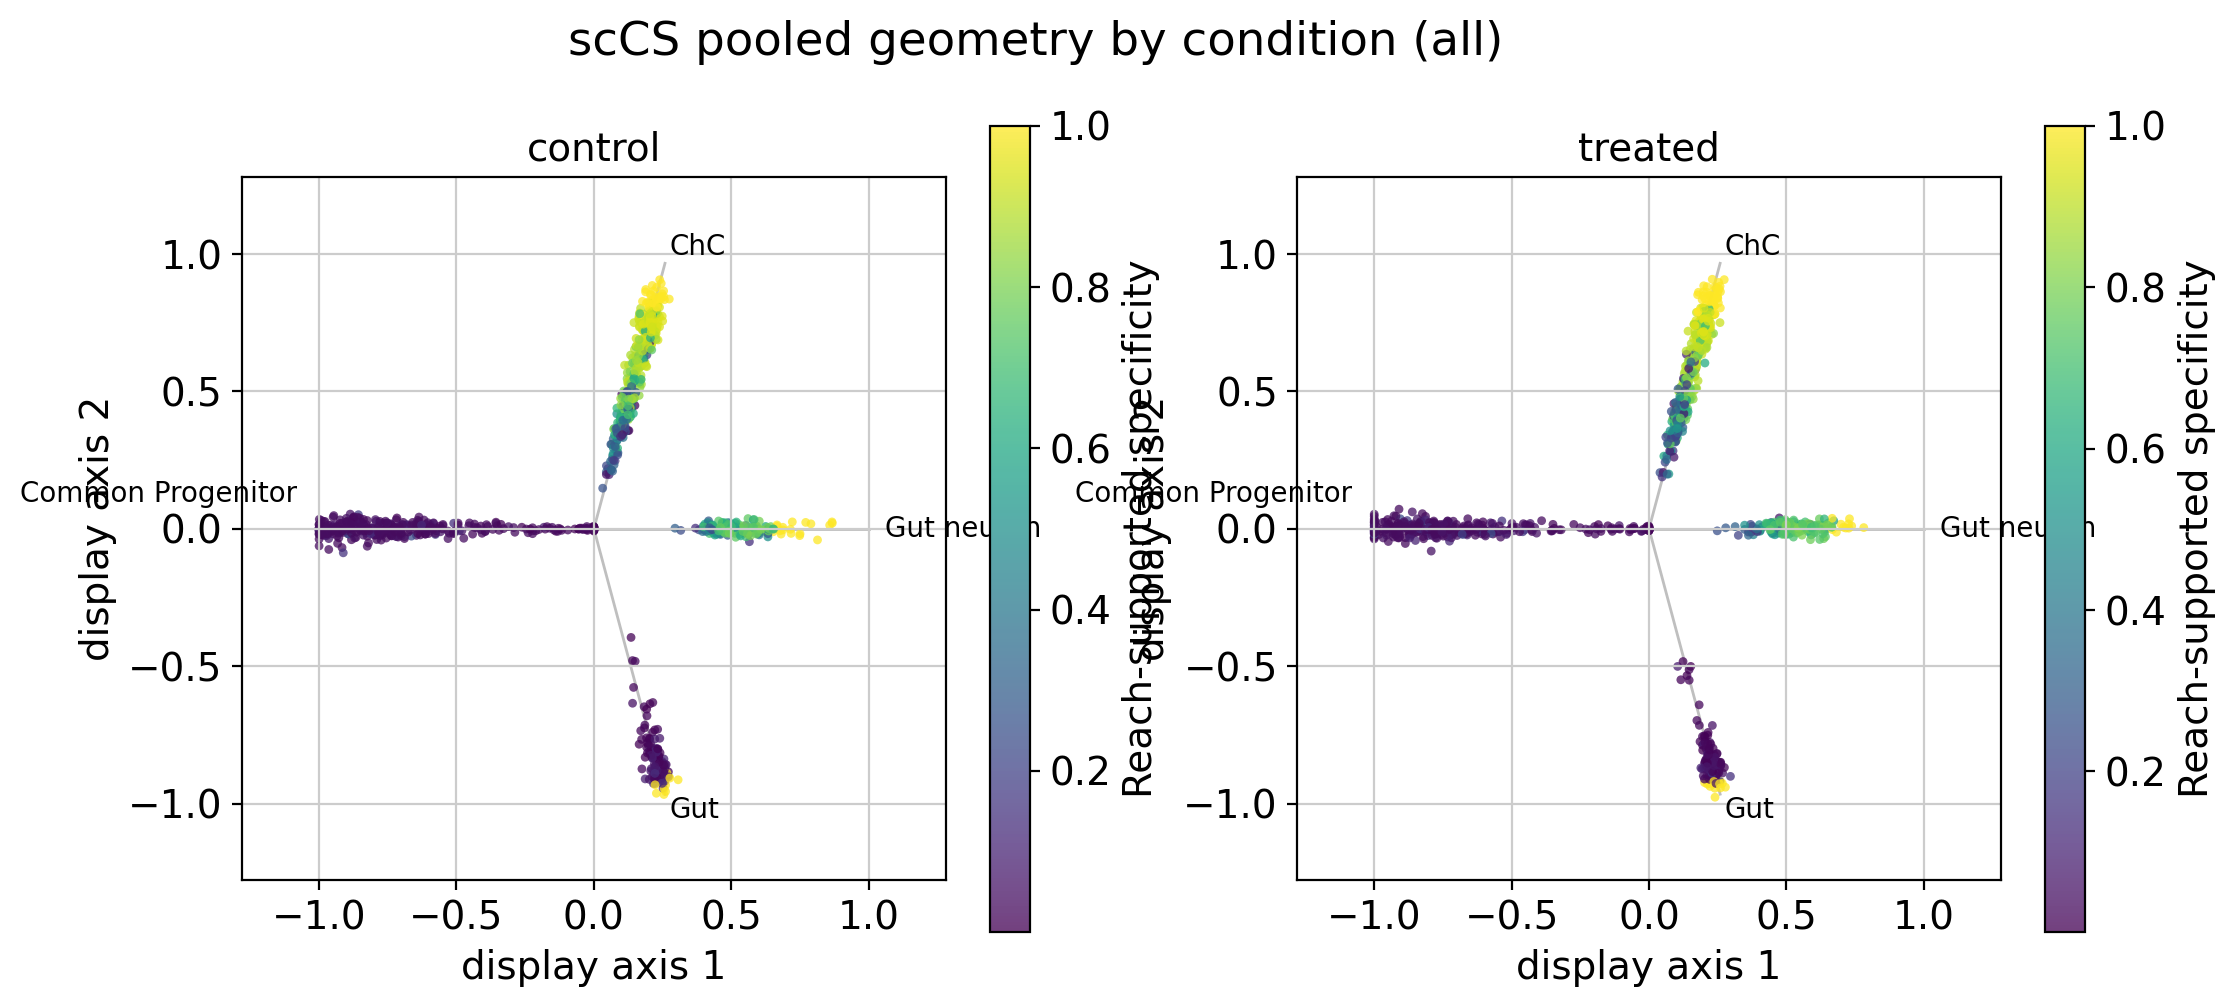

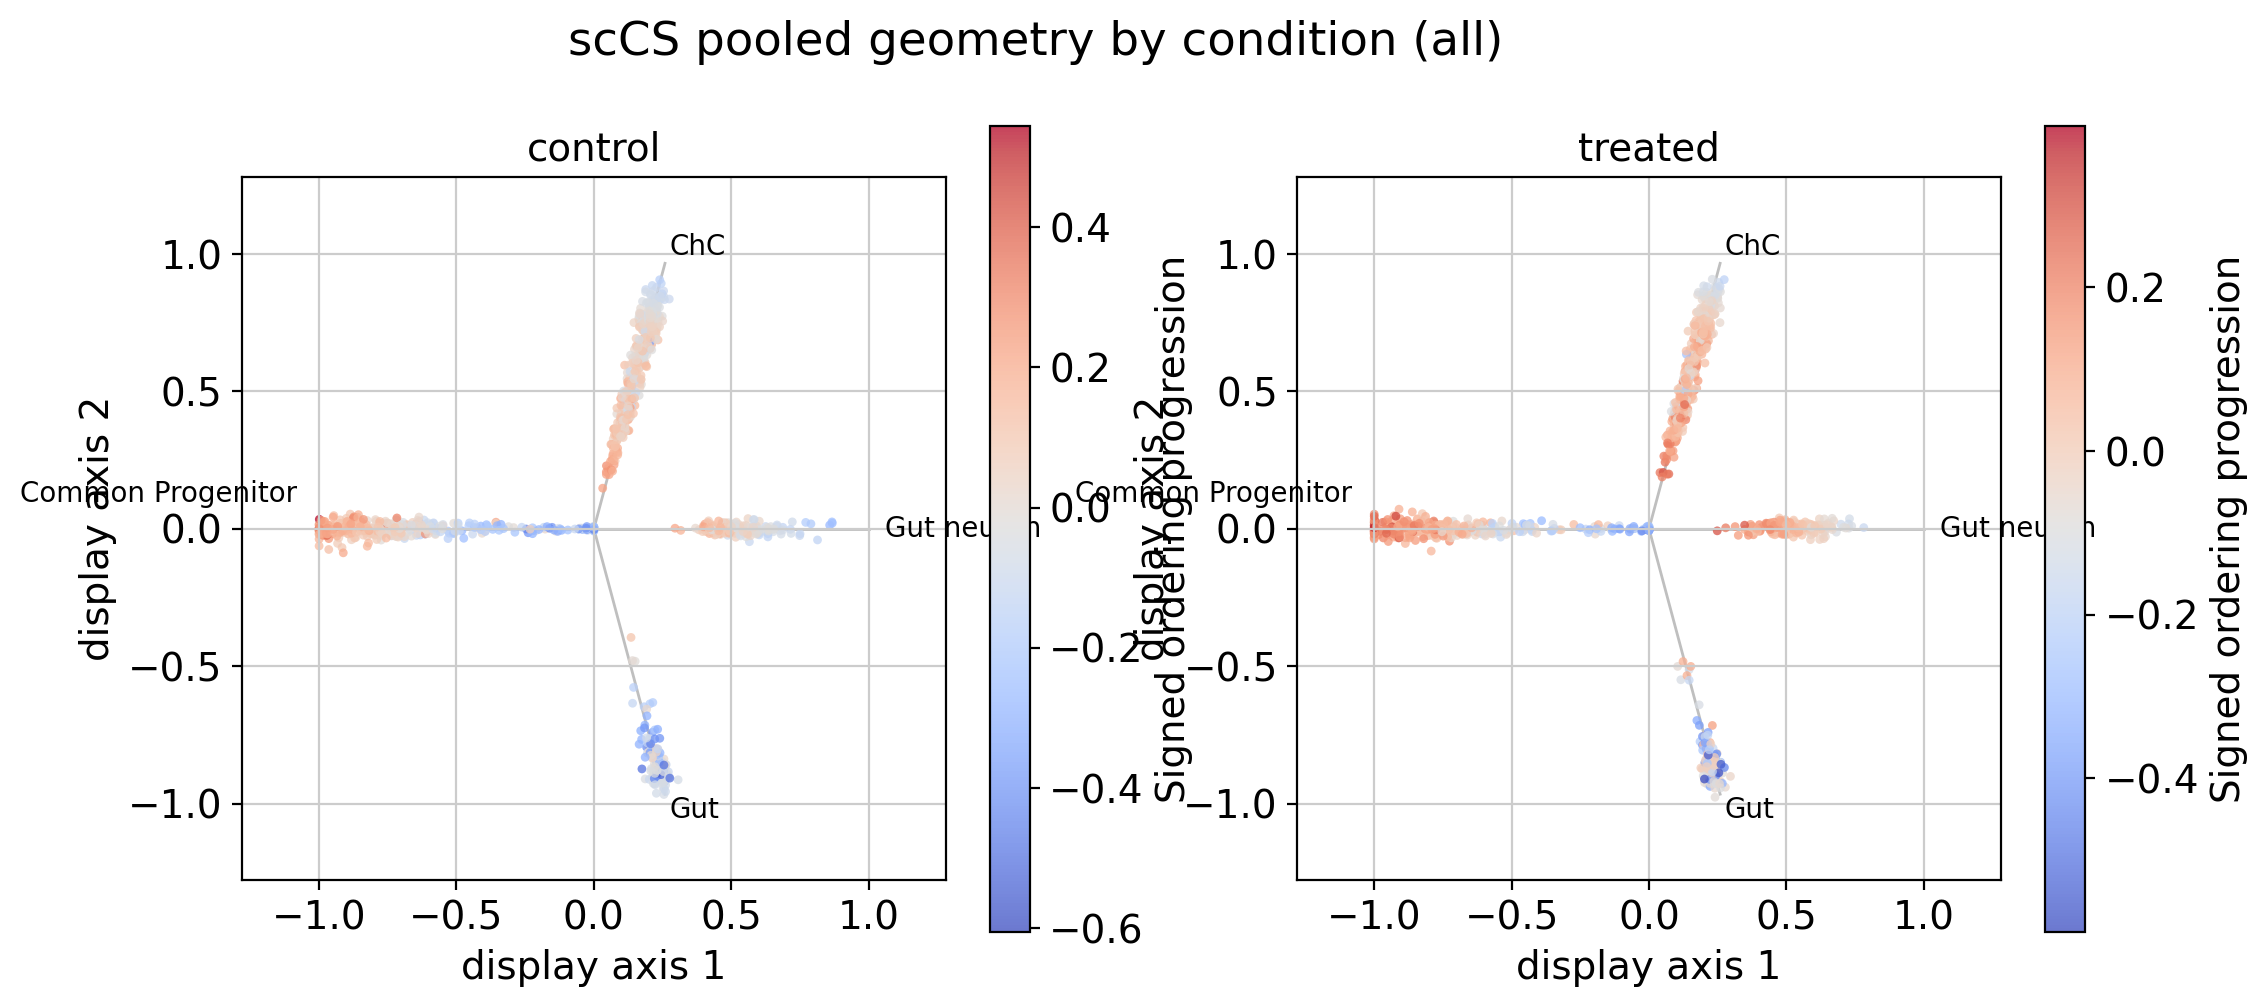

In [14]:
for color_by, filename in (
    ("population", "star_population.png"),
    (f"future_fate_affinity:{TARGET_FATE}", "star_target_affinity.png"),
    ("future_fate_reach", "star_reach.png"),
    ("future_fate_specificity", "star_specificity.png"),
    ("reach_supported_specificity", "star_supported_specificity.png"),
    ("signed_progression", "star_signed_progression.png"),
):
    figure = pair.plot_star_grid(
        results,
        color_by=color_by,
        population="all",
        ncols=2,
        cmap="coolwarm" if color_by == "signed_progression" else None,
    )
    figure.savefig(OUTPUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

## 12. Condition summaries, composition, and trajectory shifts


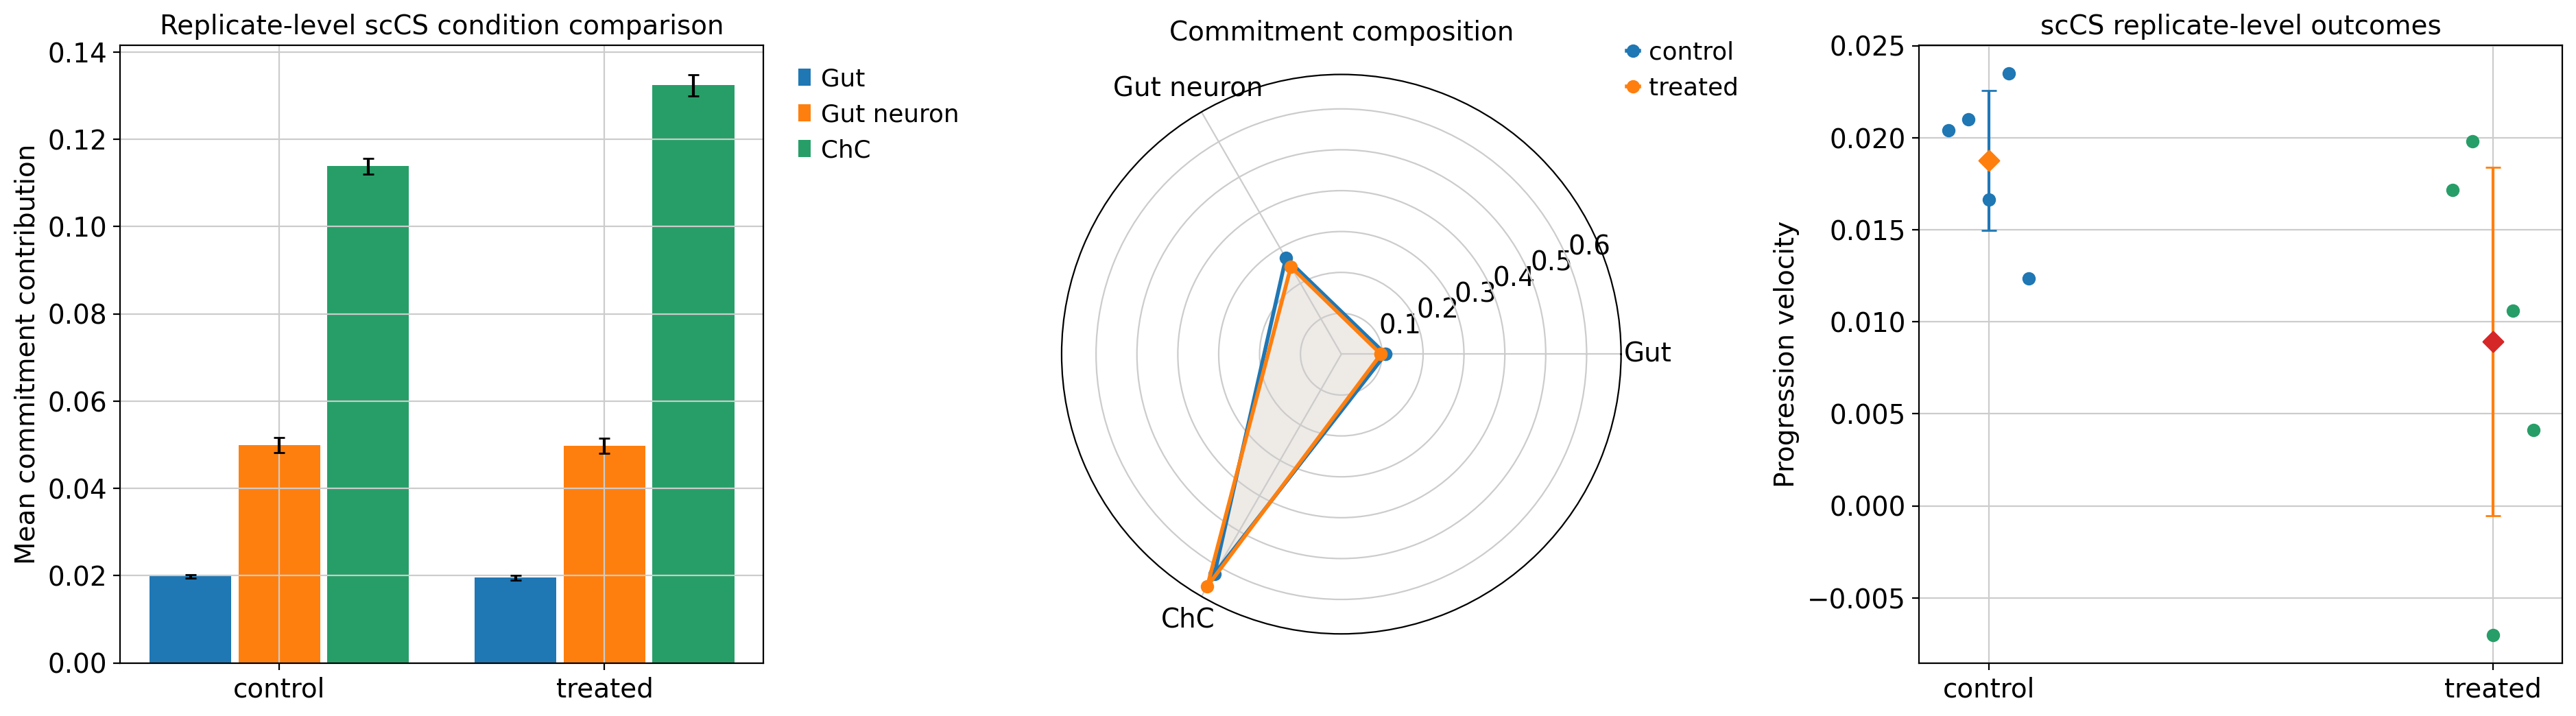

In [15]:
fig = plt.figure(figsize=(19, 5.5))
grid = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 1.15])
bar_ax = fig.add_subplot(grid[0, 0])
radar_ax = fig.add_subplot(grid[0, 1], projection="polar")
progression_ax = fig.add_subplot(grid[0, 2])

pair.plot_compare_conditions_bar(
    results,
    metric="future_fate_contribution",
    ax=bar_ax,
)
pair.plot_commitment_vector_radar(
    results,
    metric="commitment_composition",
    ax=radar_ax,
)
pair.plot_trajectory_shift(results, ax=progression_ax)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "condition_summary_visuals.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Heatmaps, status composition, and transition coverage


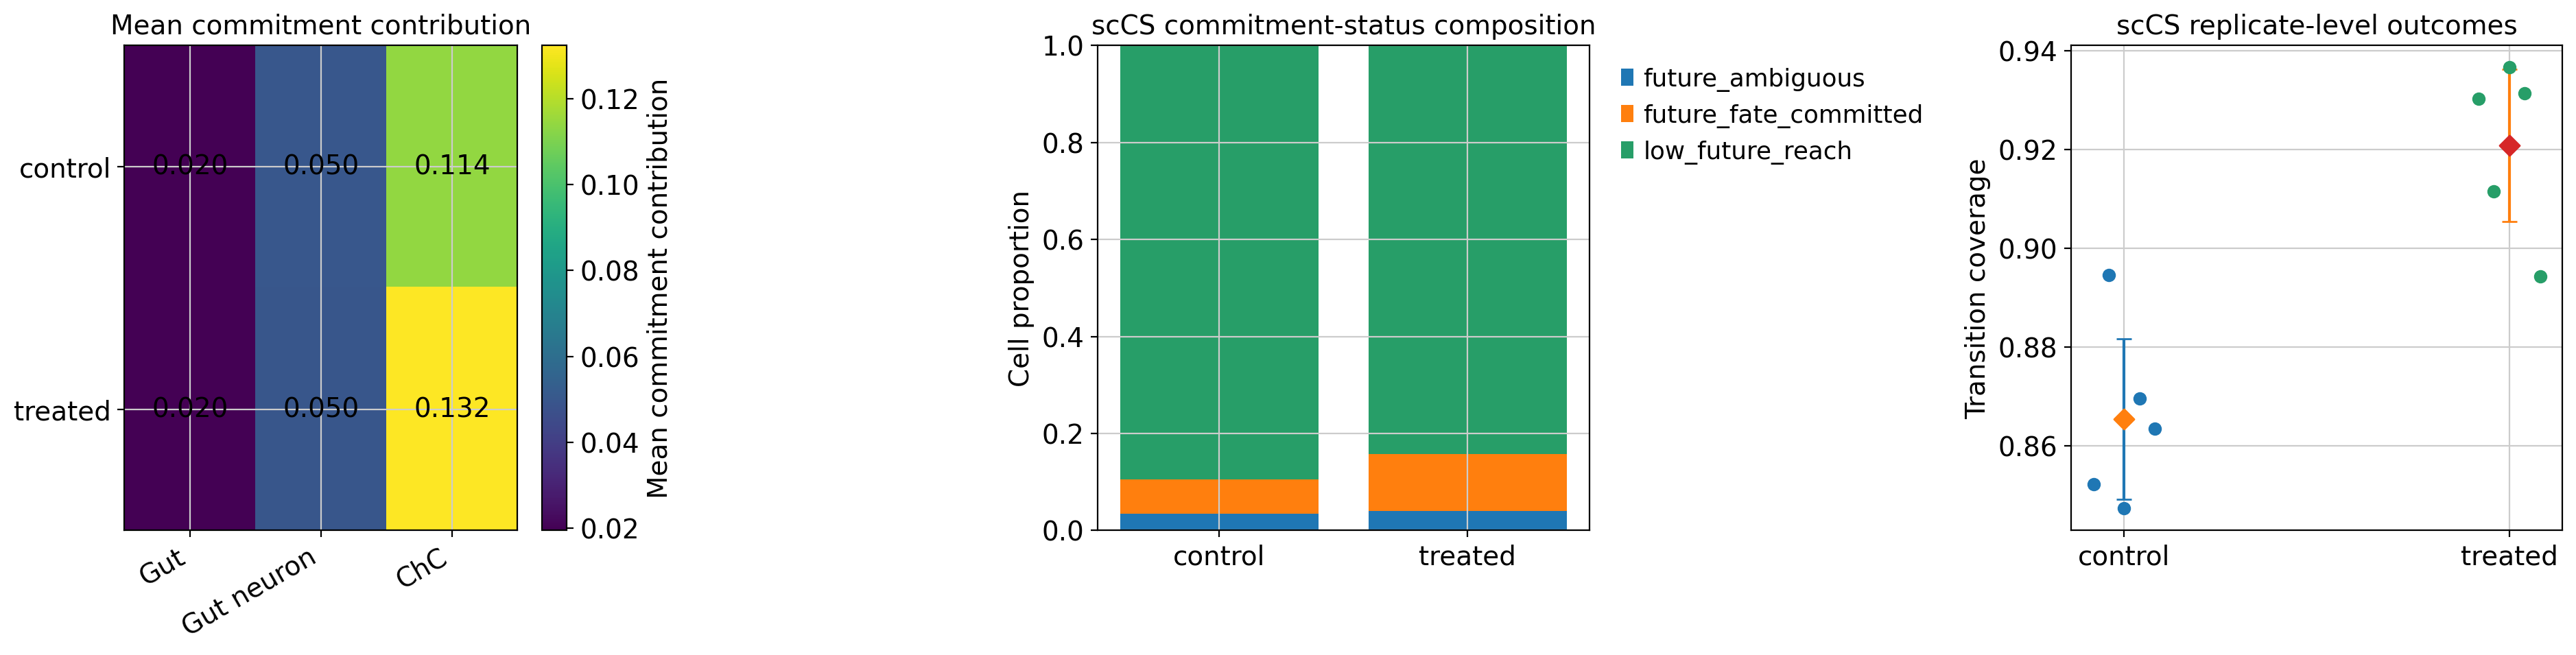

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pair.plot_commitment_heatmap(
    results,
    metric="future_fate_contribution",
    level="condition",
    annotate=True,
    ax=axes[0],
)
pair.plot_status_composition(results, ax=axes[1])
pair.plot_transition_coverage(results, ax=axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "condition_heatmap_and_qc.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Ordering trends and display-only rose plots


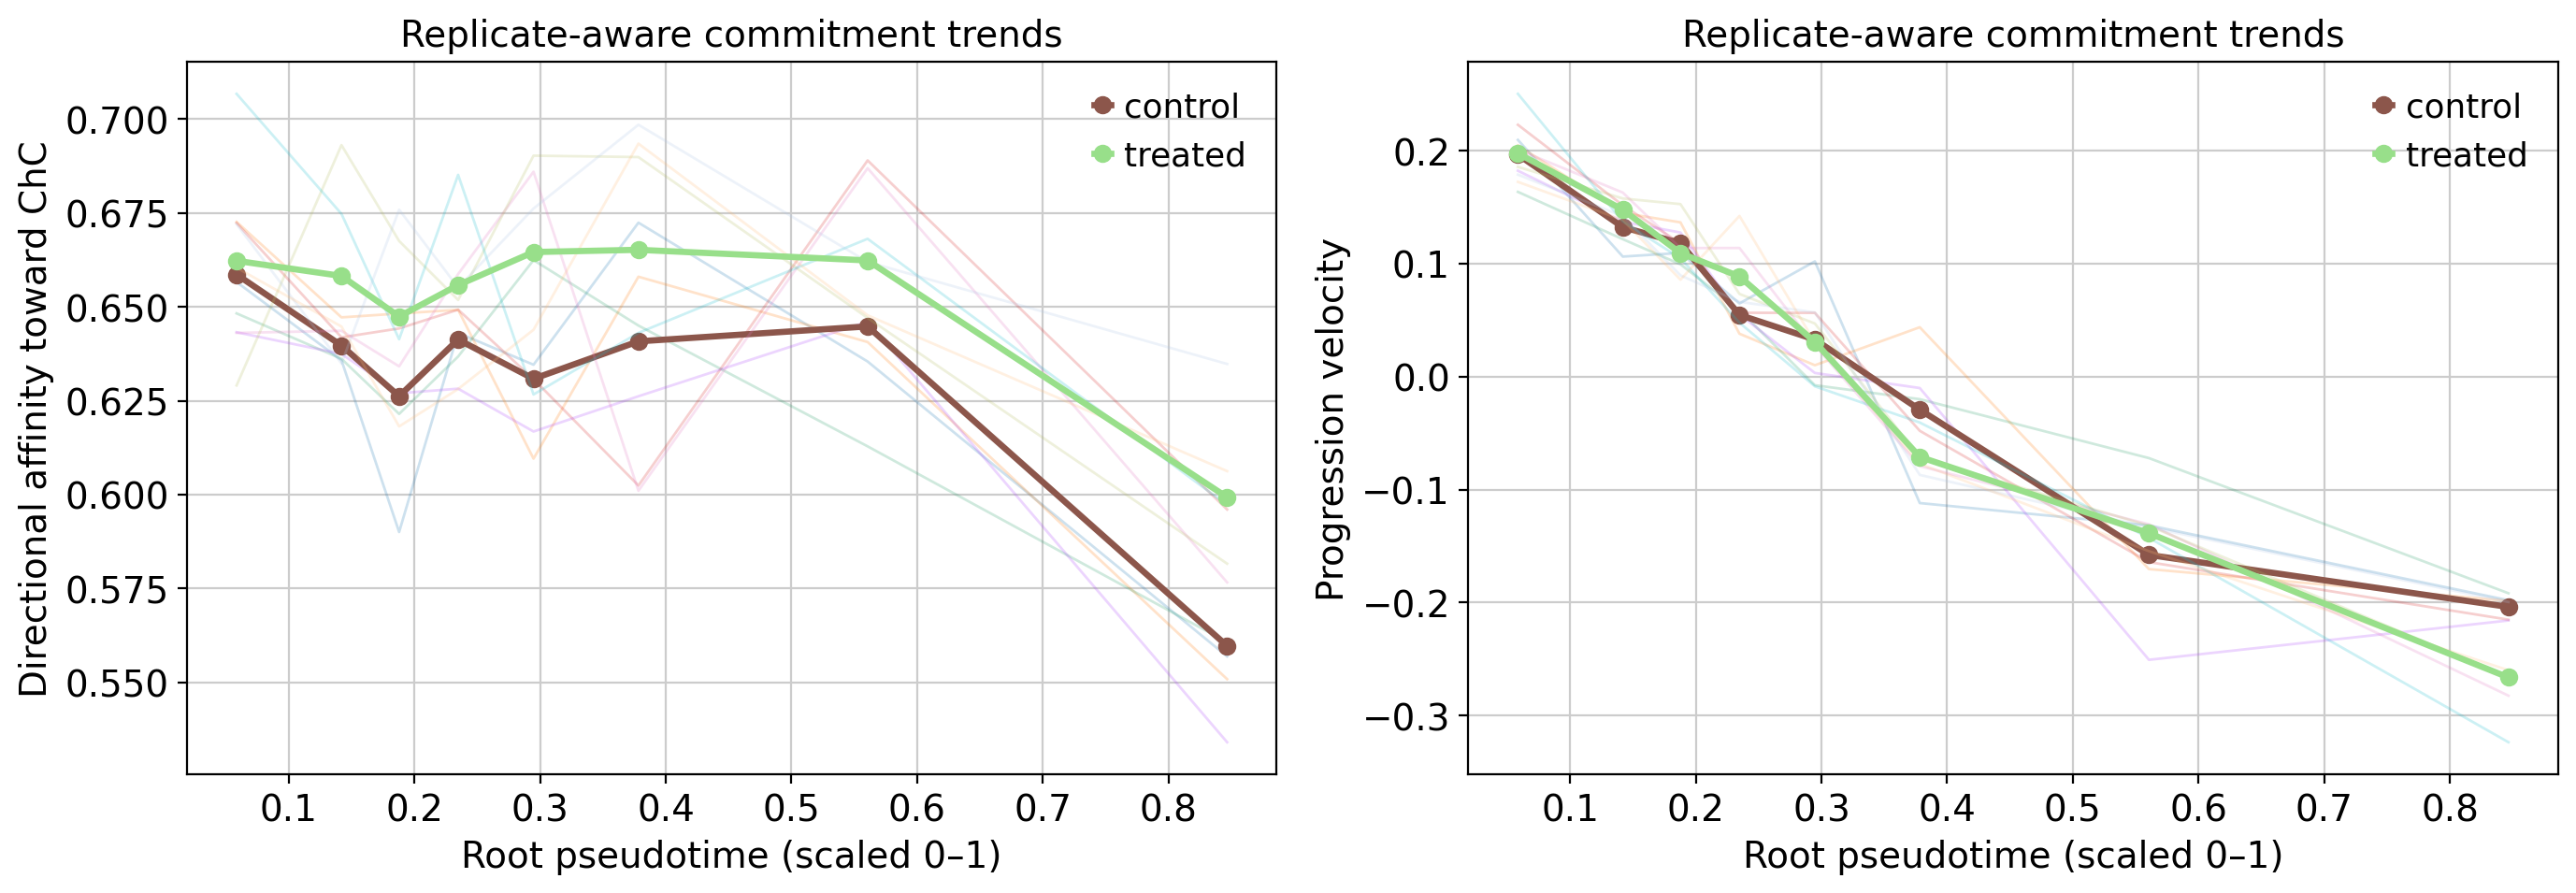

[scCS] 'control': 350 root cells; 5 replicates.
[scCS] 'treated': 325 root cells; 5 replicates.


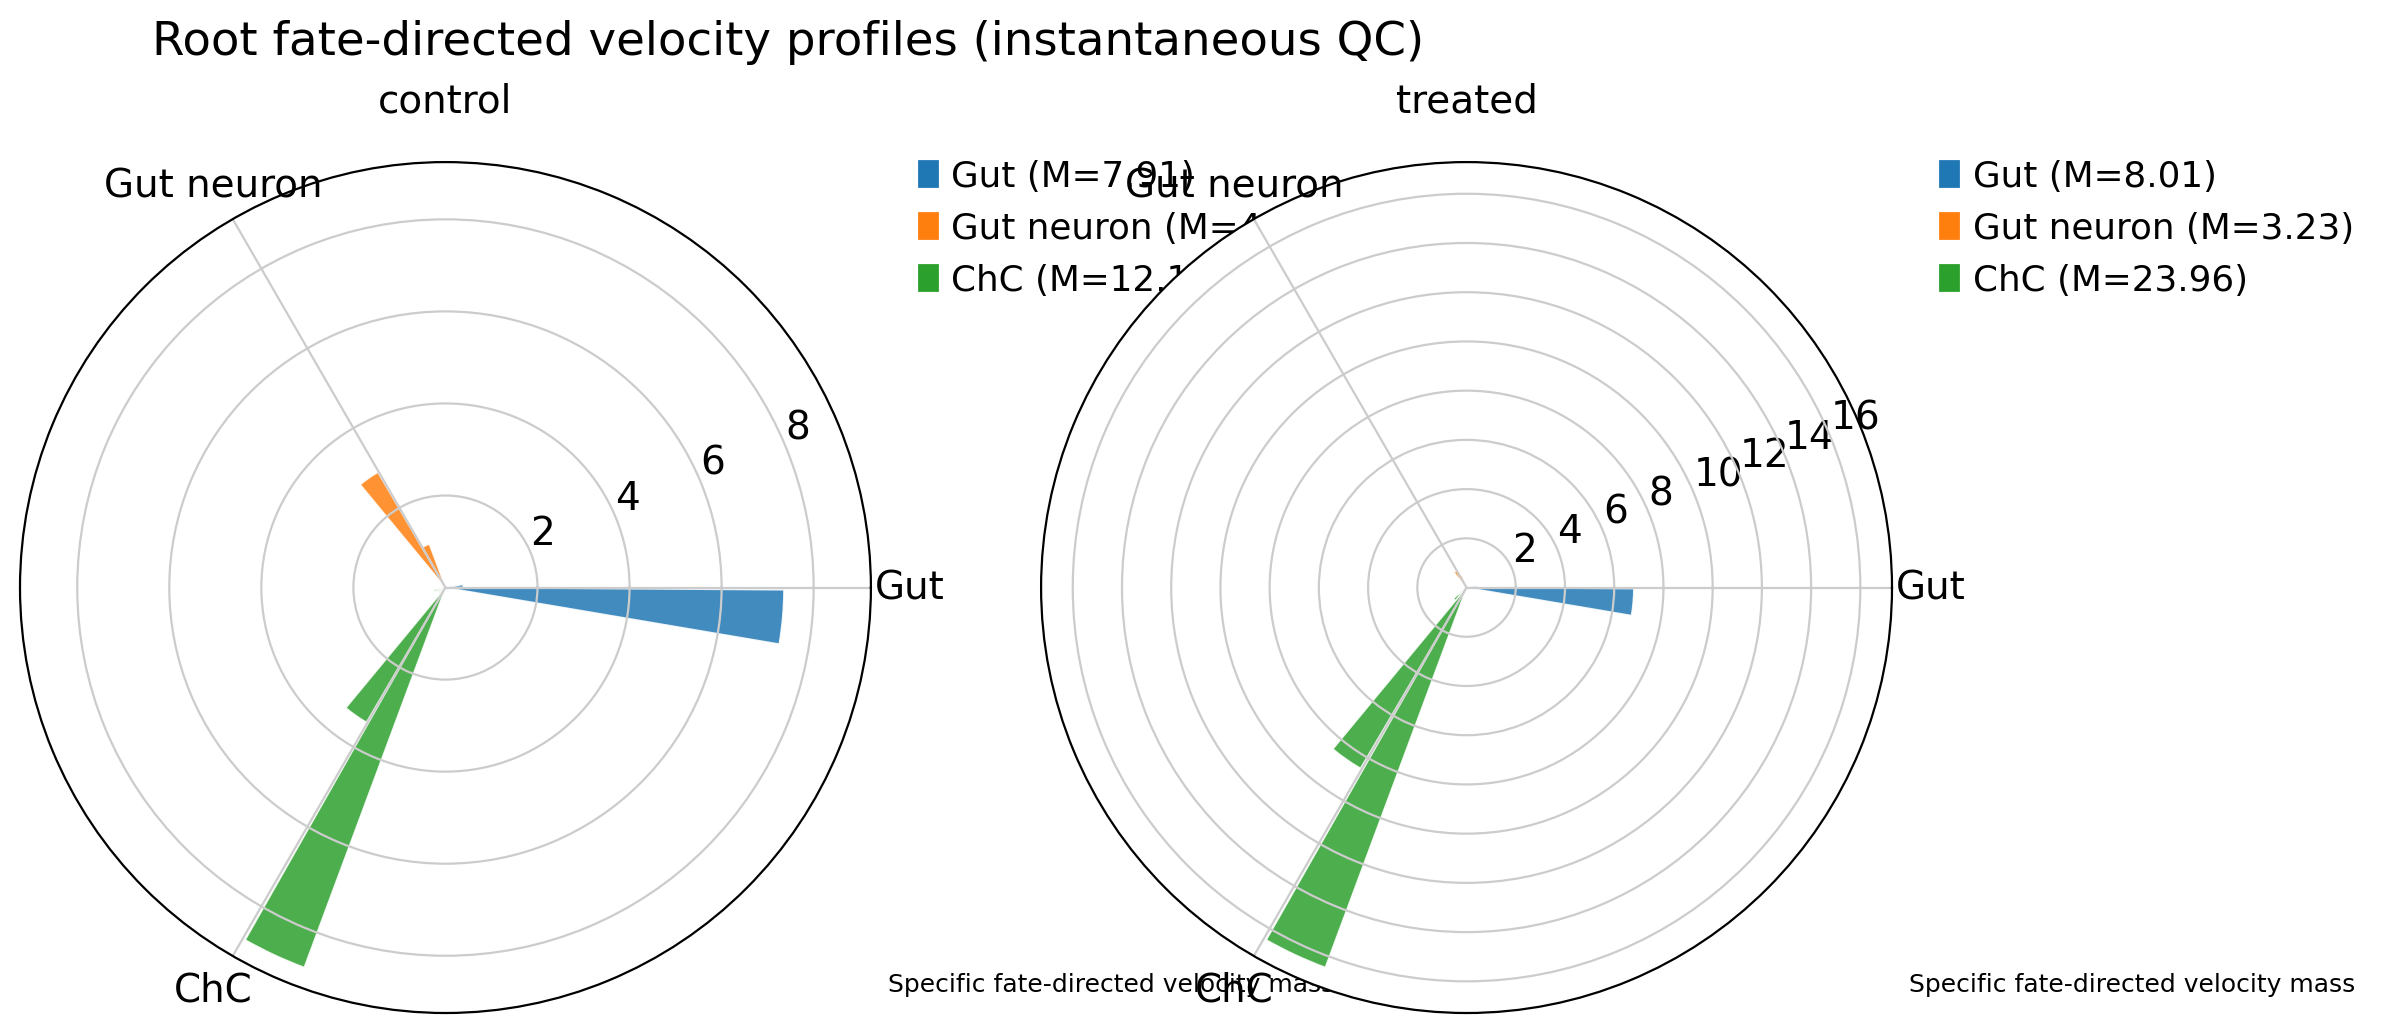

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pair.plot_pseudotime_trends(
    results,
    pseudotime_key=ORDERING_KEY,
    metric="future_fate_affinity",
    fate=TARGET_FATE,
    n_bins=8,
    show_replicates=True,
    ax=axes[0],
)
pair.plot_pseudotime_trends(
    results,
    pseudotime_key=ORDERING_KEY,
    metric="signed_progression",
    n_bins=8,
    show_replicates=True,
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ordering_trends.png", dpi=200, bbox_inches="tight")
plt.show()

# Root branch roses summarize instantaneous fate-directed velocity after
# removing incoming-root progression. They are QC views, not discounted
# future-fate probabilities. Use an independent pooled scorer.
display_pair = scCS.PairScorer(
    adata,
    root=ROOT,
    branches=FATES,
    obs_key=OBS_KEY,
    condition_obs_key=CONDITION_KEY,
    replicate_obs_key=REPLICATE_KEY,
    condition_order=list(CONDITIONS),
)
display_pair.build_embedding(ordering_metric=ORDERING_KEY, verbose=False)
display_pair.fit(
    transition_matrix=analysis_transition,
    scoring_mode="instantaneous",
    transition_scope="pooled",
    verbose=False,
)
display_results = display_pair.score_all_conditions(
    population="root",
    min_cells=1,
    min_replicates=1,
)
rose_figure = display_pair.plot_rose_grid(
    display_results,
    population="root",
    mode="branch",
    n_bins=36,
    ncols=2,
    title="Root fate-directed velocity profiles (instantaneous QC)",
)
rose_figure.savefig(OUTPUT_DIR / "display_velocity_rose_grid.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Gene expression across conditions on a shared scale


Resolved genes: ['Chga', 'Chgb', 'Dbh', 'Phox2b', 'Tubb3']
Missing genes: ['Th', 'Sox10']


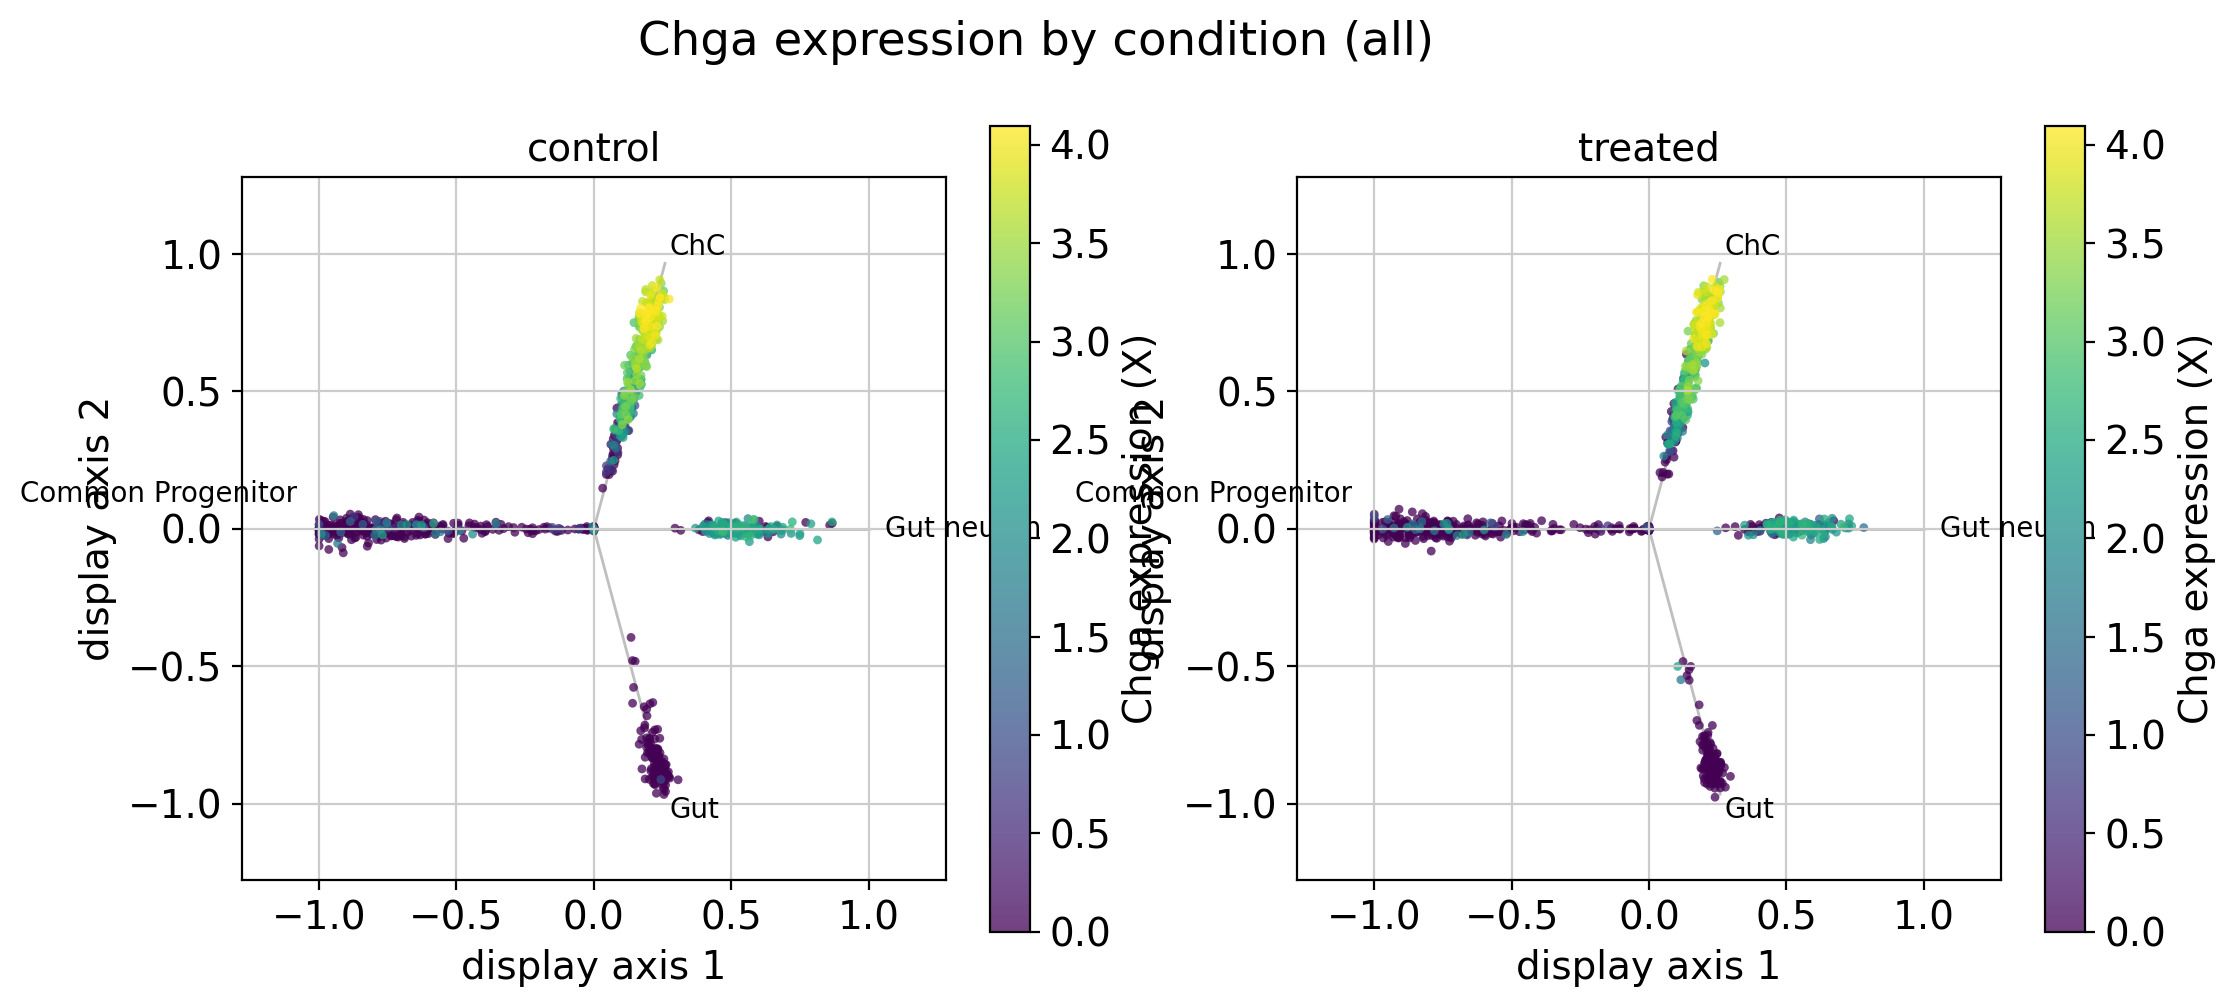

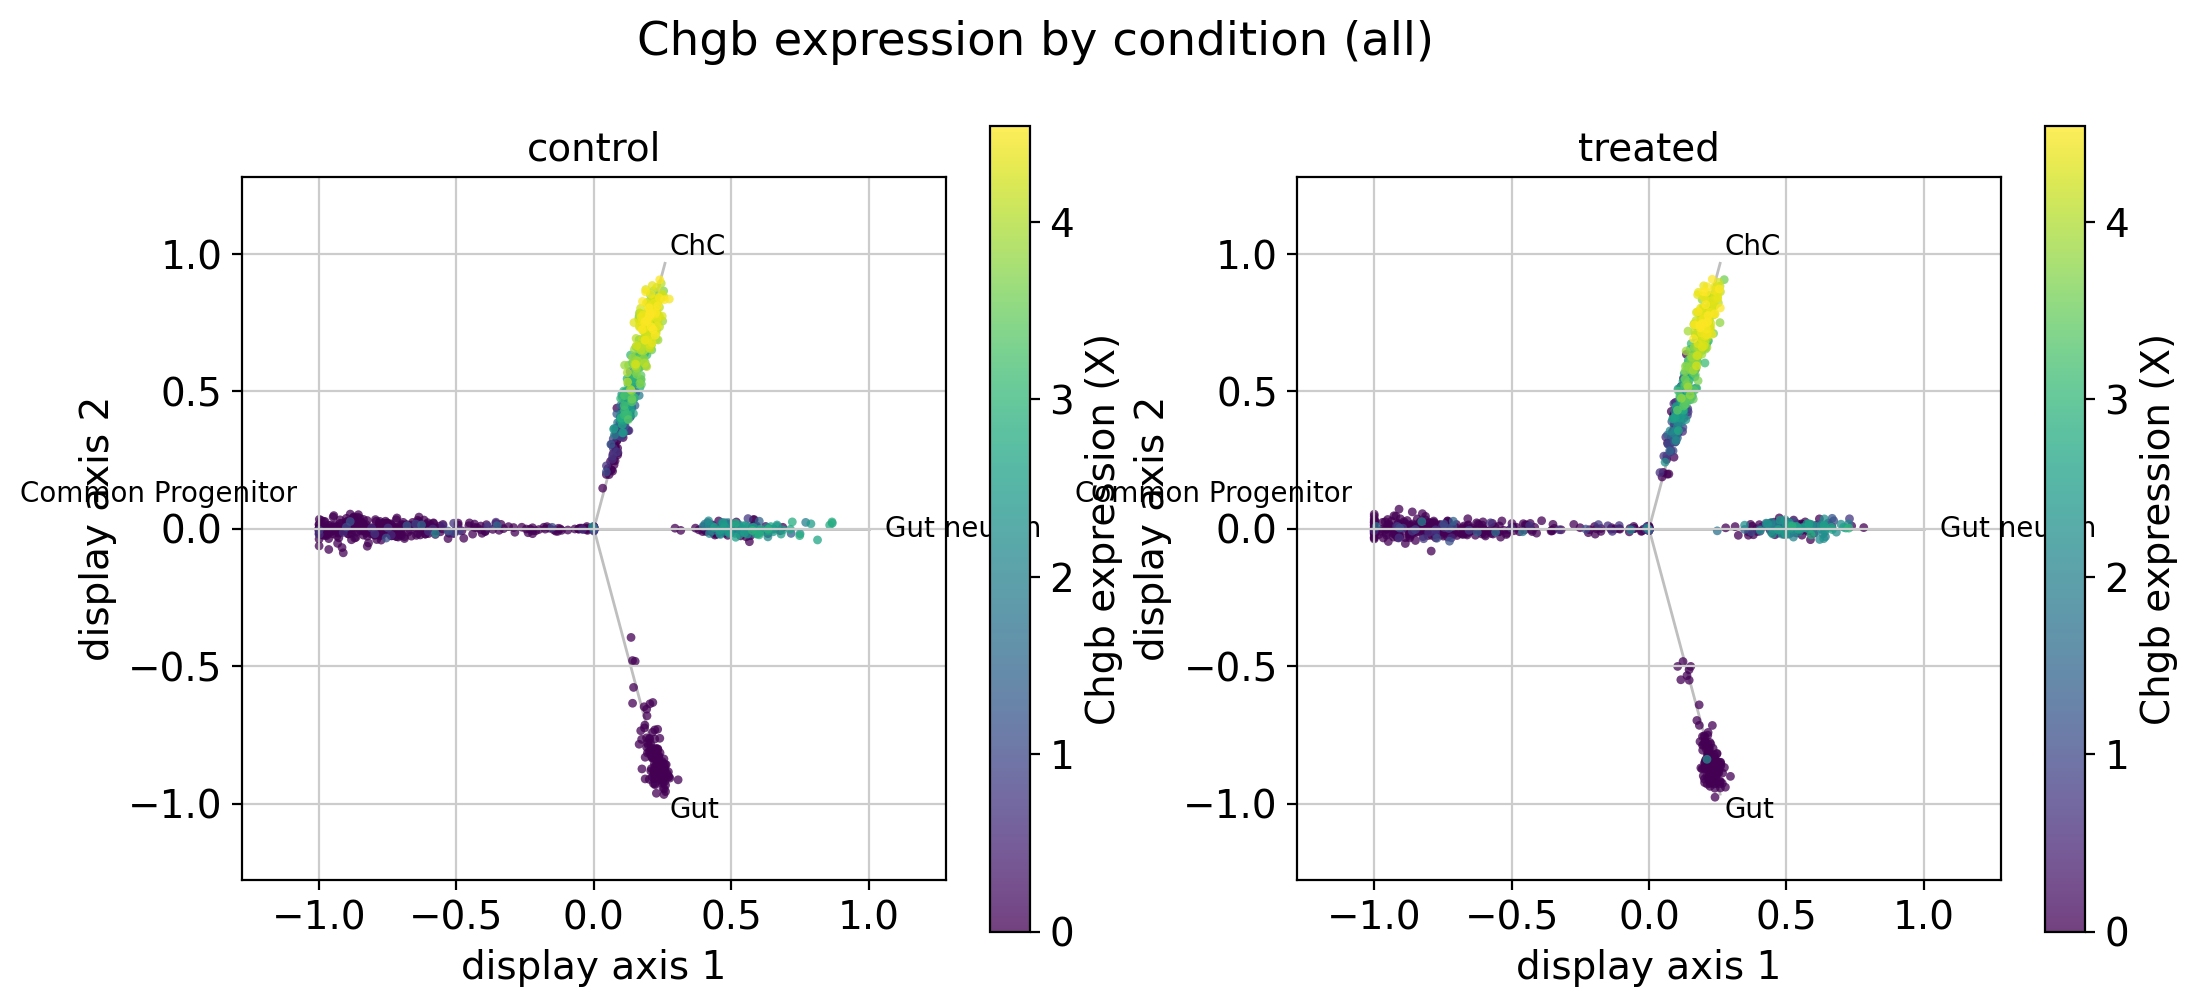

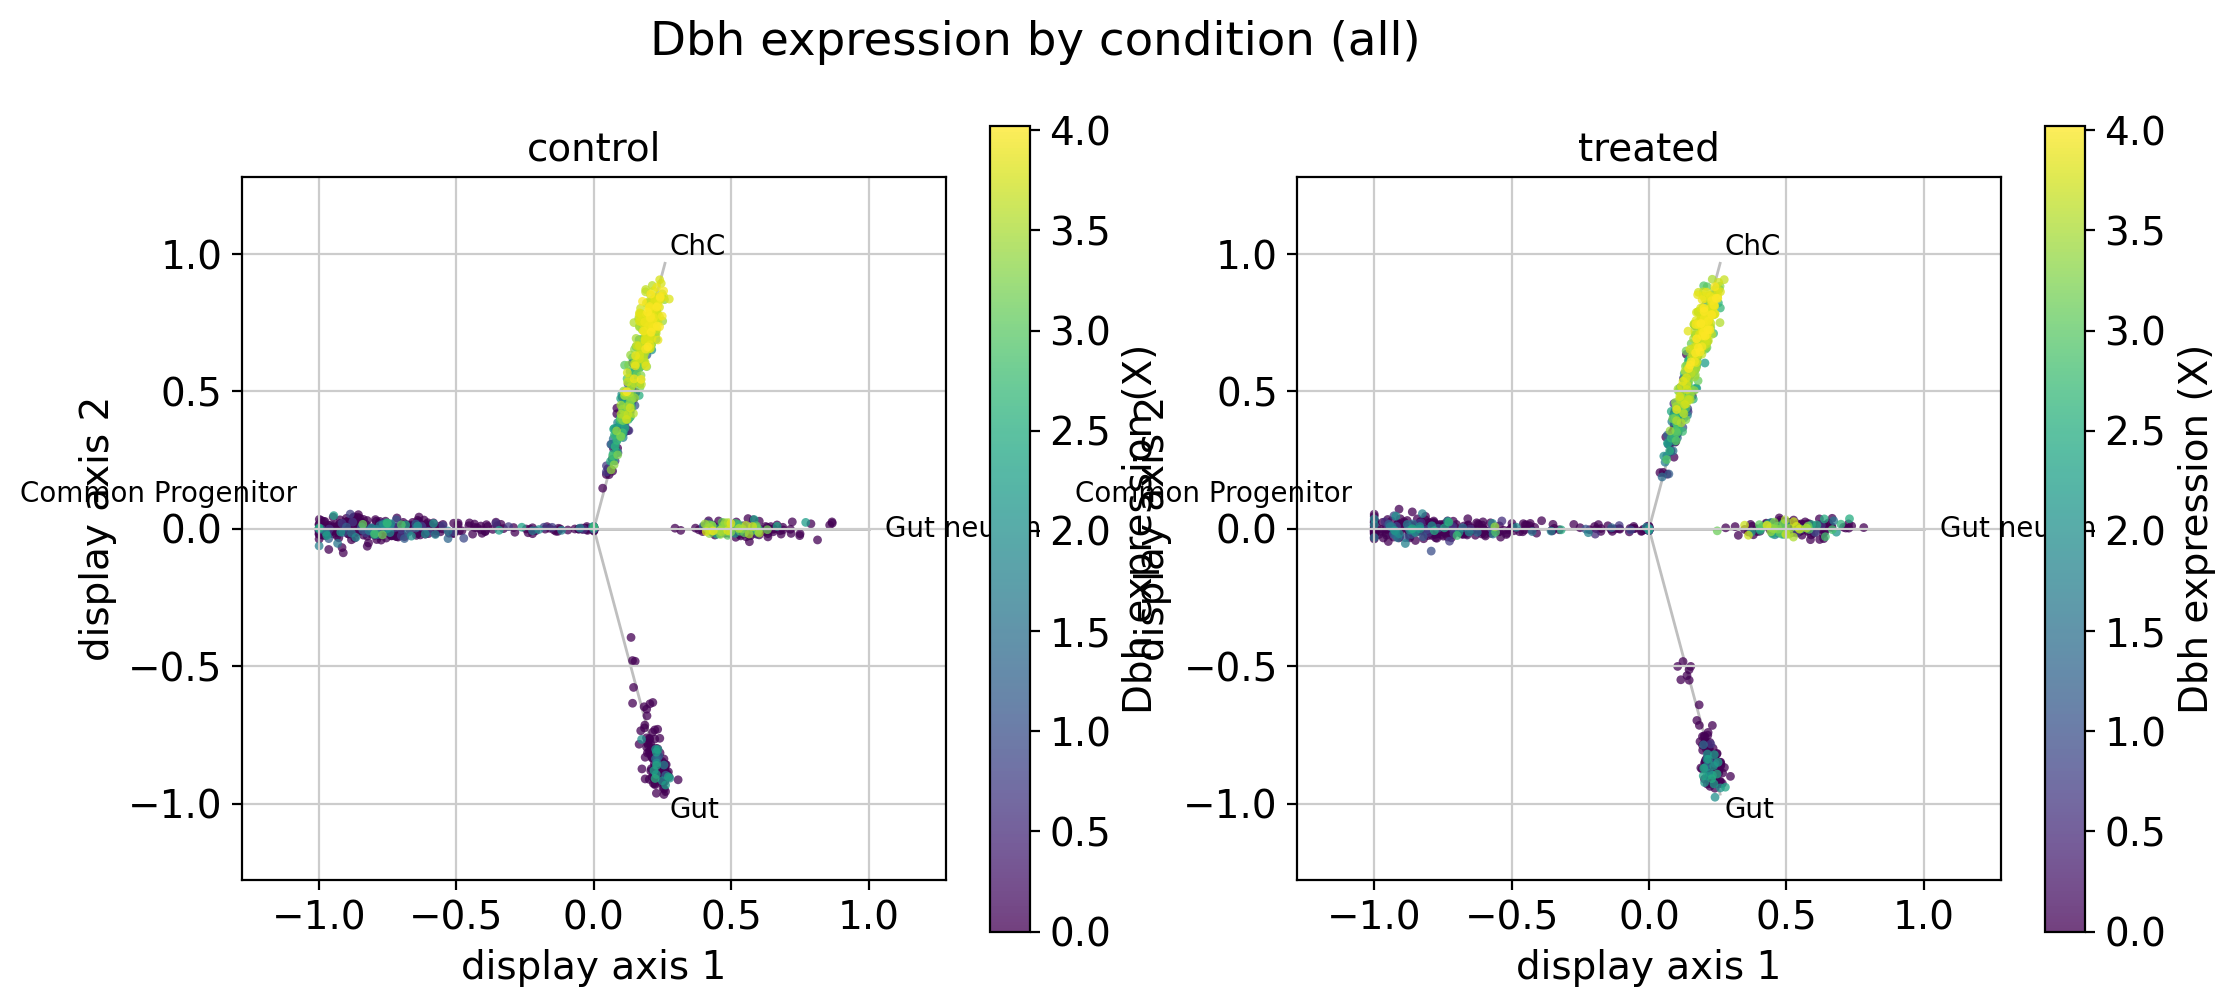

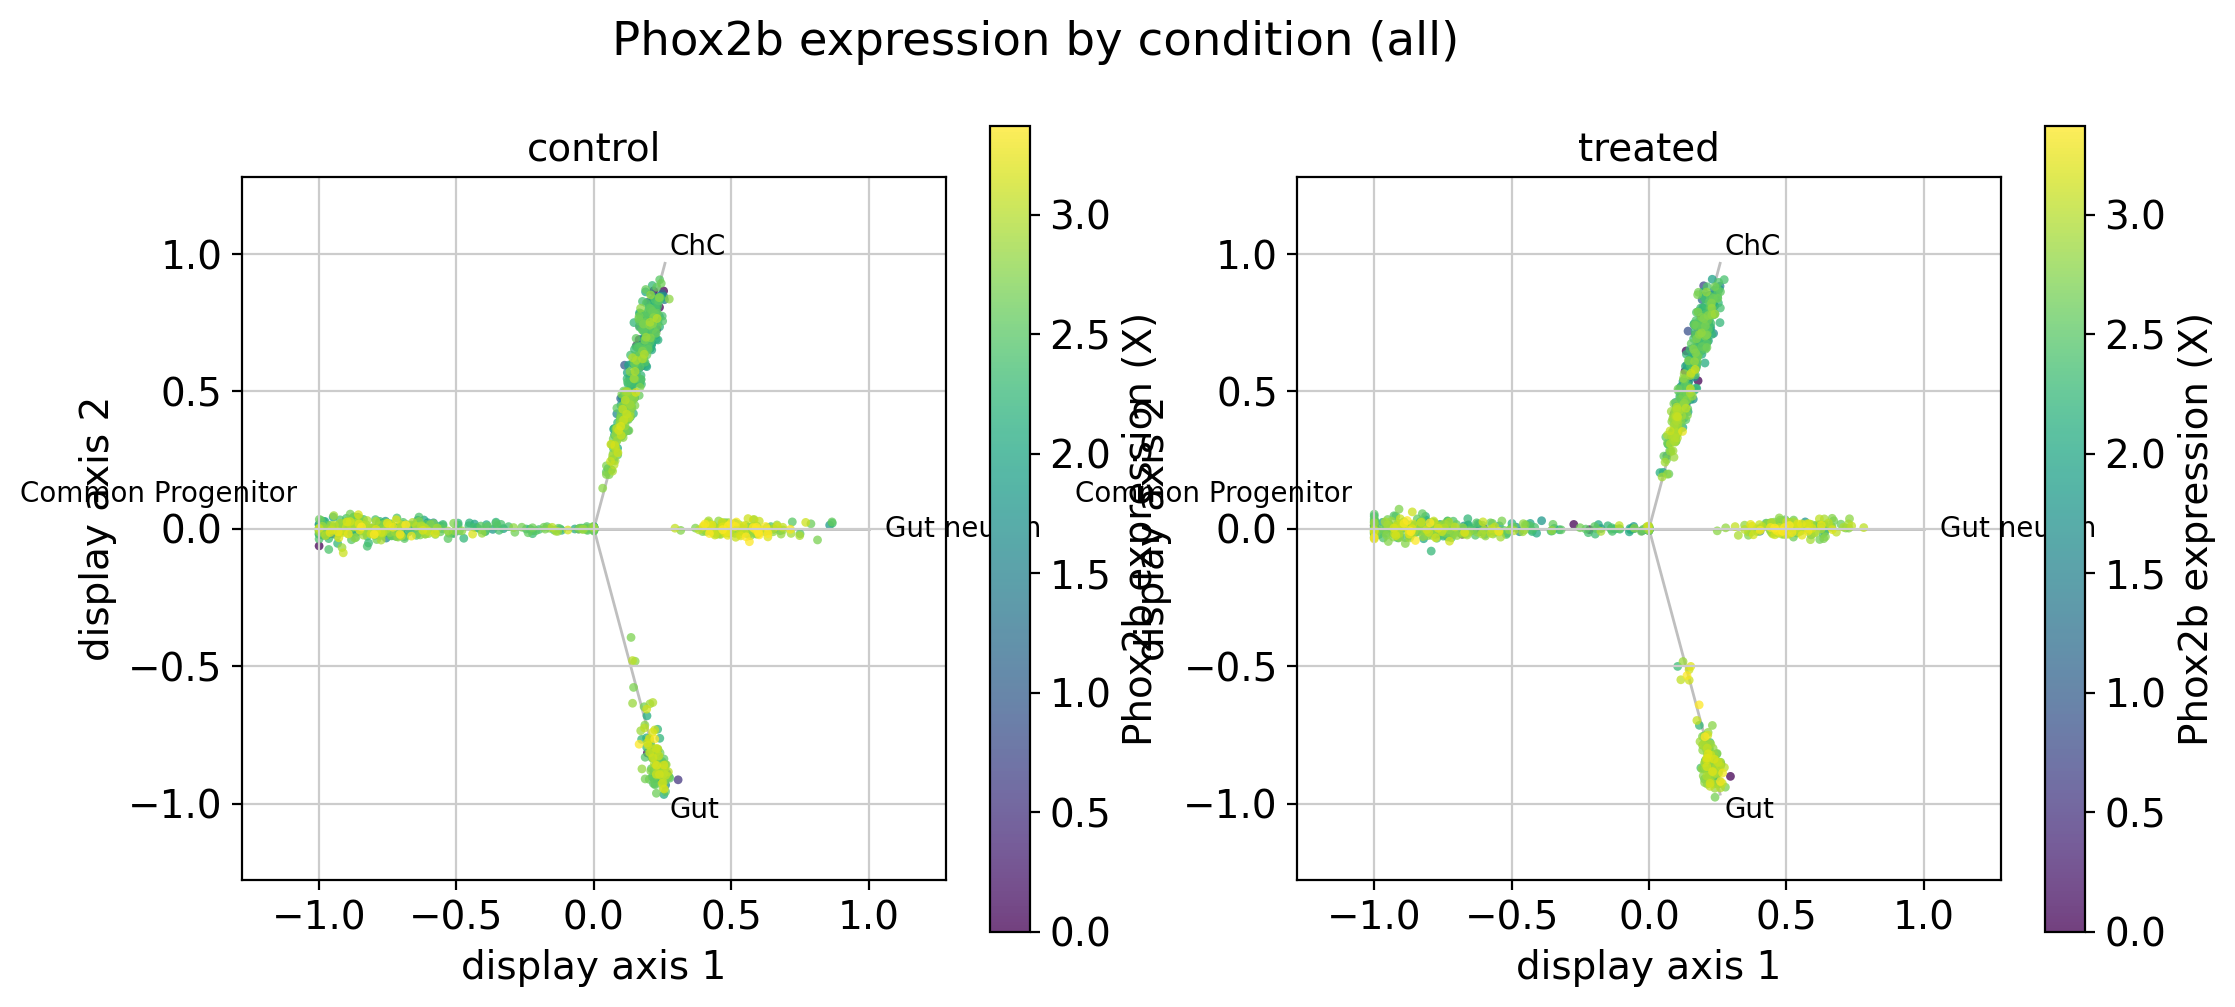

In [18]:
gene_candidates = ["Chga", "Chgb", "Th", "Dbh", "Phox2b", "Tubb3", "Sox10"]
genes, missing_genes = resolve_present_genes(adata, gene_candidates)
print("Resolved genes:", genes)
print("Missing genes:", missing_genes)
for gene in genes[:4]:
    figure = pair.plot_gene_expression_star_grid(
        gene,
        results,
        population="all",
        shared_scale=True,
        ncols=2,
    )
    figure.savefig(
        OUTPUT_DIR / f"gene_expression_{gene}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## 16. Optional transition-scope sensitivity


In [19]:
if RUN_SCOPE_SENSITIVITY:
    scope_tables = []
    for scope in ("pooled", "condition", "replicate"):
        scope_pair = scCS.PairScorer(
            adata,
            root=ROOT,
            branches=FATES,
            obs_key=OBS_KEY,
            condition_obs_key=CONDITION_KEY,
            replicate_obs_key=REPLICATE_KEY,
            condition_order=list(CONDITIONS),
        )
        scope_pair.build_embedding(ordering_metric=ORDERING_KEY, verbose=False)
        scope_pair.fit(
            transition_matrix=analysis_transition,
            transition_scope=scope,
            scoring_mode="future_fate",
            future_fate_options=FUTURE_OPTIONS,
            verbose=False,
        )
        table = scope_pair.transition_scope_summary(population="root")
        table["transition_scope"] = scope
        scope_tables.append(table)
    scope_summary = pd.concat(scope_tables, ignore_index=True)
    display(scope_summary)
    scope_summary.to_csv(OUTPUT_DIR / "transition_scope_sensitivity.csv", index=False)
else:
    print("Set RUN_SCOPE_SENSITIVITY=True to compare pooled/blocked graphs.")

Set RUN_SCOPE_SENSITIVITY=True to compare pooled/blocked graphs.


## 17. Optional fail-closed mixed-model sensitivity


In [20]:
if RUN_MIXED_MODEL_SENSITIVITY:
    mixed = pair.fit_mixed_model(
        metric="future_fate_affinity",
        fate=TARGET_FATE,
        results=results,
        on_invalid="return",
    )
    display(mixed)
    mixed.to_csv(OUTPUT_DIR / "mixed_model_sensitivity.csv", index=False)
else:
    print("Permutation and hierarchical bootstrap are the primary inference.")

Permutation and hierarchical bootstrap are the primary inference.


## 18. Export analysis objects and statistical tables


In [21]:
pair.result.write_to_adata(adata)
adata.write_h5ad(OUTPUT_DIR / "pair_scorer_analysis.h5ad")
target_affinity_stats.to_csv(OUTPUT_DIR / "primary_target_affinity_test.csv", index=False)
target_contribution_stats.to_csv(
    OUTPUT_DIR / "primary_target_contribution_test.csv",
    index=False,
)
print("Saved outputs to", OUTPUT_DIR.resolve())

Saved outputs to /home/emil/notebooks/08-tutorials/tutorial_outputs/schwann_pair


## 19. Interpretation and real-study adaptation


The controlled primary outcome is ChC future-fate affinity. Gut signed progression
remains descriptive and may be negative in both conditions. A condition effect on
fate identity is not equivalent to making every branch move outward.


For real data:

1. set `DEMO_MODE=False`;
2. provide genuine condition and independent replicate columns;
3. use the original velocity transition matrix without controlled reweighting;
4. verify condition balance, transition-scope assumptions, and replicate counts;
5. report effect sizes, raw and adjusted p-values, replicate counts, and confidence
   intervals;
6. do not treat cells as biological replicates.
